# RSNA Knee Abnormality Detection — Exploratory Data Analysis

## Objective

The goal of this competition is to predict 12 knee abnormalities from MRI studies. The training data also contain multilingual radiology reports, which may provide supervision for studies without structured target labels.

This notebook examines the dataset at the study, series, report and image levels before modelling. Particular attention is given to the unusually small gold-labelled subset, possible leakage routes, MRI acquisition variability and a reproducible validation design.

> **Important:** missing target values mean *unlabelled*, not *negative*. Series and slices from the same study must remain together, and patient-level grouping must be investigated separately.

## Dataset at a glance

| Item | Visible competition data |
|---|---:|
| Training studies | 4,407 |
| Fully gold-labelled studies | 58 |
| Report-only studies | 4,349 |
| Prediction targets | 12 |
| Training MRI series | 24,371 |
| Visible test studies | 3 |
| Predicted report languages | 9 |

## Contents

1. [Setup](#setup)
2. [Competition file structure](#understanding-the-competition-file-structure)
3. [Tabular data and label coverage](#loading-the-tabular-data)
4. [Multi-label target analysis](#multi-label-target-analysis)
5. [Radiology report analysis](#radiology-report-analysis)
6. [MRI series metadata](#mri-series-metadata)
7. [Study–series integrity](#studyseries-data-integrity)
8. [Image structure and sampled integrity](#image-file-structure)
9. [Validation strategy](#validation-strategy)
10. [Candidate imaging inputs](#candidate-imaging-inputs)
11. [Conclusions and limitations](#conclusions-limitations-and-modelling-implications)

References: [competition page](https://www.kaggle.com/competitions/rsna-knee-abnormality-detection) · [DICOM Image Plane Module](https://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_C.7.6.2.html)


# Setup

In [1]:
# 1. Notebook step
# ============================================================
# 1. Imports and reproducibility
# ============================================================

from pathlib import Path
from collections import Counter
import os
import warnings
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
DATA_ROOT = Path("/kaggle/input")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

print(f"NumPy:      {metadata.version('numpy')}")
print(f"Pandas:     {metadata.version('pandas')}")
print(f"Matplotlib: {metadata.version('matplotlib')}")
print(f"Seaborn:    {metadata.version('seaborn')}")
print(f"Random seed: {RANDOM_STATE}")
print(f"Input root:  {DATA_ROOT}")


NumPy:      2.0.2
Pandas:     2.3.3
Matplotlib: 3.10.0
Seaborn:    0.13.2
Random seed: 42
Input root:  /kaggle/input


In [2]:
# 2. Notebook step
# ============================================================
# 2. Initial input inventory
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Could not find {DATA_ROOT}")

def describe_entry(path):
    """Create a compact summary of a file or directory."""
    if path.is_file():
        return {
            "name": path.name,
            "type": "file",
            "size_mb": path.stat().st_size / 1024**2,
            "children": np.nan,
        }

    children = list(path.iterdir())

    return {
        "name": path.name,
        "type": "directory",
        "size_mb": np.nan,
        "children": len(children),
    }

input_summary = pd.DataFrame(
    [describe_entry(path) for path in sorted(DATA_ROOT.iterdir())]
)

display(input_summary)


,name,type,size_mb,children
0,competitions,directory,NaN,1


# Understanding the competition file structure

We first inspect the directory structure and file types before loading any data.

This is important because medical-imaging competitions often contain several levels of organisation, such as:

- patients
- studies
- series
- image files
- tabular metadata or labels

In [3]:
# 3. Notebook step
# ============================================================
# 3. Inspect competition directory structure
# ============================================================

COMPETITIONS_ROOT = DATA_ROOT / "competitions"

def preview_directory(path, limit=50):
    """
    Display only the first few entries in a directory.
    This avoids scanning the entire image dataset.
    """
    rows = []

    with os.scandir(path) as entries:
        for index, entry in enumerate(entries):
            if index >= limit:
                break

            entry_path = Path(entry.path)
            is_directory = entry.is_dir(follow_symlinks=False)

            rows.append({
                "name": entry.name,
                "type": "directory" if is_directory else "file",
                "size_mb": (
                    np.nan
                    if is_directory
                    else entry.stat(follow_symlinks=False).st_size / 1024**2
                ),
            })

    return pd.DataFrame(rows)


print(f"Competition directory: {COMPETITIONS_ROOT}")

competition_directories = sorted(
    path for path in COMPETITIONS_ROOT.iterdir()
    if path.is_dir()
)

print("\nCompetition folders:")
for path in competition_directories:
    print(f"  - {path.name}")

print("\nPreview of competition directory:")
display(preview_directory(COMPETITIONS_ROOT))


Competition directory: /kaggle/input/competitions

Competition folders:
  - rsna-knee-abnormality-detection

Preview of competition directory:


,name,type,size_mb
0,rsna-knee-abnormality-detection,directory,NaN


In [4]:
# 4. Preview the competition files

COMPETITION_NAME = "rsna-knee-abnormality-detection"
COMPETITION_ROOT = COMPETITIONS_ROOT / COMPETITION_NAME

if not COMPETITION_ROOT.exists():
    raise FileNotFoundError(
        f"Competition directory not found: {COMPETITION_ROOT}"
    )

print(f"Selected competition folder: {COMPETITION_ROOT}")
display(preview_directory(COMPETITION_ROOT, limit=100))


Selected competition folder: /kaggle/input/competitions/rsna-knee-abnormality-detection


,name,type,size_mb
0,test_series.csv,file,0.0021
1,train_series.csv,file,3.2986
2,sample_submission.csv,file,0.0004
3,test_series,directory,NaN
4,train_series,directory,NaN
5,train.csv,file,5.4264
6,test.csv,file,0.0002


# Loading the tabular data

The competition provides several CSV files describing the studies and imaging series.

We will initially work with the tabular files only. The image directories are much larger, so we will inspect them separately after understanding the metadata.

In [5]:
# 5. Notebook step
# ============================================================
# 5. Load the tabular competition files
# ============================================================

TRAIN_PATH = COMPETITION_ROOT / "train.csv"
TEST_PATH = COMPETITION_ROOT / "test.csv"
TRAIN_SERIES_PATH = COMPETITION_ROOT / "train_series.csv"
TEST_SERIES_PATH = COMPETITION_ROOT / "test_series.csv"
SAMPLE_SUBMISSION_PATH = COMPETITION_ROOT / "sample_submission.csv"

table_paths = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
    "train_series": TRAIN_SERIES_PATH,
    "test_series": TEST_SERIES_PATH,
    "sample_submission": SAMPLE_SUBMISSION_PATH,
}

missing_files = [
    str(path)
    for path in table_paths.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following expected files were not found:\n"
        + "\n".join(missing_files)
    )

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
train_series = pd.read_csv(TRAIN_SERIES_PATH)
test_series = pd.read_csv(TEST_SERIES_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

tables = {
    "train": train,
    "test": test,
    "train_series": train_series,
    "test_series": test_series,
    "sample_submission": sample_submission,
}

print("All tabular files loaded successfully.")


All tabular files loaded successfully.


## Initial table overview

The first question is how many rows and columns each table contains.

The number of rows does not necessarily equal the number of patients or studies. A single study may contain multiple imaging series, and a single series may contain multiple images.

In [6]:
# 6. Notebook step
# ============================================================
# 6. Compare table sizes
# ============================================================

table_overview = pd.DataFrame([
    {
        "table": name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "memory_mb": dataframe.memory_usage(deep=True).sum() / 1024**2,
    }
    for name, dataframe in tables.items()
])

display(table_overview)


,table,rows,columns,memory_mb
0,train,4407,14,7.2340
1,test,3,1,0.0004
2,train_series,24371,5,6.9244
3,test_series,15,5,0.0044
4,sample_submission,3,13,0.0007


## Column and data-quality overview

We now inspect the columns, data types, number of unique values and missing values.

This will help us identify:

- identifier columns;
- target columns;
- categorical metadata;
- numerical metadata;
- columns that are constant or nearly constant; and
- possible data-quality problems.

In [7]:
# 7. Notebook step
# ============================================================
# 7. Inspect columns and missing values
# ============================================================

schema_rows = []

for table_name, dataframe in tables.items():
    for column in dataframe.columns:
        schema_rows.append({
            "table": table_name,
            "column": column,
            "dtype": str(dataframe[column].dtype),
            "unique_values": dataframe[column].nunique(dropna=False),
            "missing_values": dataframe[column].isna().sum(),
            "missing_percent": (
                dataframe[column].isna().mean() * 100
            ),
        })

schema = (
    pd.DataFrame(schema_rows)
    .sort_values(["table", "column"])
    .reset_index(drop=True)
)

display(schema)


,table,column,dtype,unique_values,missing_values,missing_percent
0,sample_submission,ACL,float64,1,0,0.0000
1,sample_submission,Baker's,float64,1,0,0.0000
2,sample_submission,Contusion,float64,1,0,0.0000
3,sample_submission,Effusion,float64,1,0,0.0000
4,sample_submission,Fracture,float64,1,0,0.0000
5,sample_submission,Lateral Meniscus,float64,1,0,0.0000
6,sample_submission,Lateral OA,float64,1,0,0.0000
7,sample_submission,MCL,float64,1,0,0.0000
8,sample_submission,Medial Meniscus,float64,1,0,0.0000
9,sample_submission,Medial OA,float64,1,0,0.0000


In [8]:
# 8. Notebook step
# ============================================================
# 8. Preview each table
# ============================================================

for table_name, dataframe in tables.items():
    print(f"\n{table_name.upper()}")
    display(dataframe.head())



TRAIN


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TEST


,StudyInstanceUID
0,1.2.826.0.1.3680043.8.498.10047035057544427318...
1,1.2.826.0.1.3680043.8.498.10062861783145312629...
2,1.2.826.0.1.3680043.8.498.10067514707072572280...



TRAIN_SERIES


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal



TEST_SERIES


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,0,0,Axial
1,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.17811502614030631664...,0,0,Sagittal
2,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.30565395595045942404...,0,0,Sagittal
3,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.32856494541816845805...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.44334485654554877495...,1,1,Axial



SAMPLE_SUBMISSION


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000


## Labels and target coverage

The training table contains 4,407 studies, but the abnormality labels are not available for every study.

This distinction is important:

- a value of `0` means the abnormality was not identified;
- a value of `1` means the abnormality was identified; and
- a missing value means that the study is unlabelled.

Therefore, missing labels must not be interpreted as normal studies.

In [9]:
# 9. Notebook step
# ============================================================
# 9. Identify target columns and label coverage
# ============================================================

ID_COLUMN = "StudyInstanceUID"

TARGET_COLUMNS = [
    column
    for column in sample_submission.columns
    if column != ID_COLUMN
]

print("Target columns:")
print(TARGET_COLUMNS)

labels_per_row = train[TARGET_COLUMNS].notna().sum(axis=1)

label_status = pd.Series(
    np.select(
        [
            labels_per_row == 0,
            labels_per_row == len(TARGET_COLUMNS),
        ],
        [
            "Unlabelled",
            "Fully labelled",
        ],
        default="Partially labelled",
    ),
    name="label_status",
)

label_status_summary = (
    label_status
    .value_counts()
    .rename_axis("label_status")
    .reset_index(name="number_of_studies")
)

label_status_summary["percentage"] = (
    label_status_summary["number_of_studies"]
    / len(train)
    * 100
)

display(label_status_summary)


Target columns:
['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,label_status,number_of_studies,percentage
0,Unlabelled,4349,98.6839
1,Fully labelled,58,1.3161


### Key findings

Only **58 of the 4,407 training studies (1.32%)** contain expert-structured labels for the 12 target abnormalities. The remaining **4,349 studies (98.68%)** contain MRI data and a radiology report but no structured target values.

There are no partially labelled studies: each study either has all 12 structured targets or none of them.

This is an intentional feature of the competition rather than a missing-data error. The 58 labelled studies form a small **gold-label subset**, while the reports provide weak supervision for the much larger unlabelled subset.

The reports offer a possible source of additional supervision—for example through multilingual NLP, clinical rules or an LLM-based label extractor. Their usefulness and noise must be measured rather than assumed, and purely image-based or externally pretrained approaches remain possible.

Missing targets must never be converted directly to zero: `NaN` means unlabelled, whereas `0` means an abnormality was assessed as absent.

## Label distribution

We now examine the abnormality labels among the labelled studies only.

The prevalence figures below describe the labelled subset. They should not be interpreted as prevalence estimates for all 4,407 training studies because most studies do not have labels.

In [10]:
# 10. Notebook step
# ============================================================
# 10. Target distribution among labelled studies
# ============================================================

fully_labelled_mask = labels_per_row == len(TARGET_COLUMNS)
labelled_train = train.loc[fully_labelled_mask].copy()

target_summary_rows = []

for target in TARGET_COLUMNS:
    values = labelled_train[target].dropna()

    target_summary_rows.append({
        "target": target,
        "labelled_studies": len(values),
        "positive_cases": int((values == 1).sum()),
        "negative_cases": int((values == 0).sum()),
        "positive_percentage": (values == 1).mean() * 100,
        "unique_values": sorted(values.unique().tolist()),
    })

target_summary = (
    pd.DataFrame(target_summary_rows)
    .sort_values("positive_percentage", ascending=False)
    .reset_index(drop=True)
)

display(target_summary)


,target,labelled_studies,positive_cases,negative_cases,positive_percentage,unique_values
0,Effusion,58,35,23,60.3448,"[0.0, 1.0]"
1,Synovitis,58,27,31,46.5517,"[0.0, 1.0]"
2,Medial Meniscus,58,26,32,44.8276,"[0.0, 1.0]"
3,ACL,58,24,34,41.3793,"[0.0, 1.0]"
4,Lateral Meniscus,58,23,35,39.6552,"[0.0, 1.0]"
5,PF OA,58,21,37,36.2069,"[0.0, 1.0]"
6,Contusion,58,19,39,32.7586,"[0.0, 1.0]"
7,Fracture,58,18,40,31.0345,"[0.0, 1.0]"
8,Medial OA,58,15,43,25.8621,"[0.0, 1.0]"
9,Baker's,58,12,46,20.6897,"[0.0, 1.0]"


In [11]:
# 11. Notebook step
# ============================================================
# 11. Validate target values
# ============================================================

observed_target_values = set(
    labelled_train[TARGET_COLUMNS]
    .to_numpy()
    .ravel()
)

expected_target_values = {0.0, 1.0}
unexpected_target_values = observed_target_values - expected_target_values

assert not unexpected_target_values, (
    f"Unexpected target values found: {unexpected_target_values}"
)

print("Target validation passed.")
print("All labelled target values are binary: 0 or 1.")


Target validation passed.
All labelled target values are binary: 0 or 1.


### Key findings

All observed targets are binary, with values of either `0` or `1`. This confirms that each abnormality is formulated as a separate binary classification target.

The positive rates vary considerably across the 12 abnormalities:

- **Effusion** is the most frequent, appearing in 35 of 58 labelled studies (60.3%).
- **Synovitis**, **Medial Meniscus injury** and **ACL injury** are also relatively common.
- **MCL injury** is the least frequent, appearing in only 9 studies (15.5%).
- **Lateral OA** and **Baker's cyst** are similarly uncommon.

Across all targets, there are 240 positive labels among 58 studies, equivalent to approximately **4.14 positive abnormalities per study**. The targets are therefore not mutually exclusive: an individual study can contain several abnormalities.

Because the labelled sample is very small, these percentages are uncertain and should not be interpreted as estimates of prevalence in the full dataset or the general population. The rare targets will also make validation particularly challenging. For example, a five-fold split would contain only around one or two positive MCL cases in each validation fold.

# Multi-label target analysis

Each study can contain more than one abnormality. We will examine both the balance of the individual targets and the relationships between them.

All results in this section refer only to the 58 gold-labelled studies.

## Individual target balance

The chart below compares the positive rate of each target within the gold-labelled subset.

Because only 58 studies are available, these rates are descriptive rather than reliable population prevalence estimates.

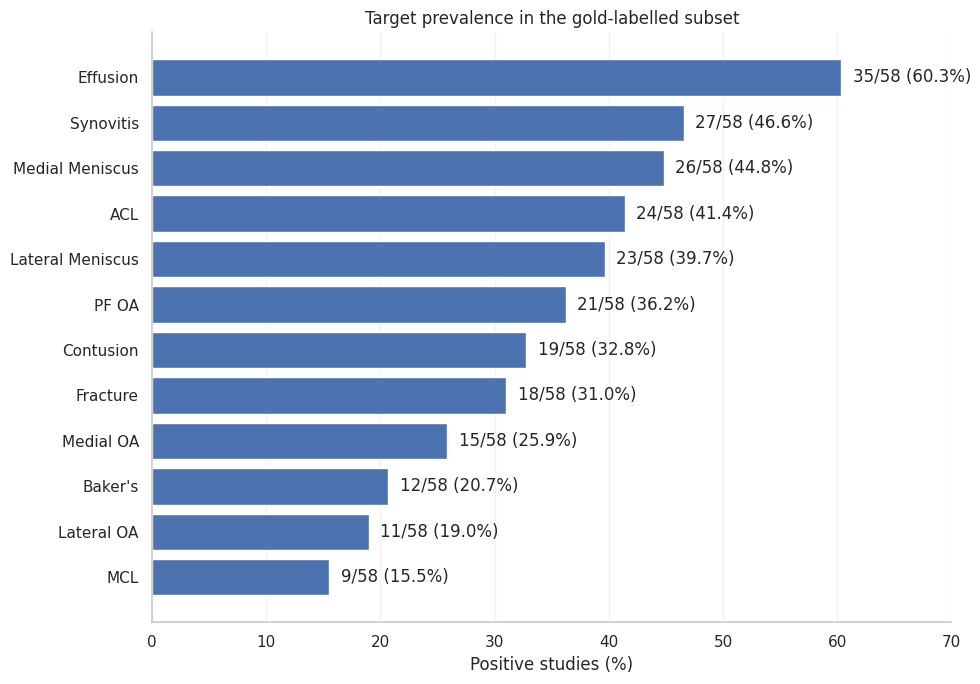

In [12]:
# 12. Notebook step
# ============================================================
# 12. Visualise individual target prevalence
# ============================================================

prevalence_plot = (
    target_summary
    .sort_values("positive_percentage")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    prevalence_plot["target"],
    prevalence_plot["positive_percentage"],
    color=sns.color_palette("deep")[0],
)

for bar, positive_cases, percentage in zip(
    bars,
    prevalence_plot["positive_cases"],
    prevalence_plot["positive_percentage"],
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{positive_cases}/58 ({percentage:.1f}%)",
        va="center",
    )

ax.set_xlim(0, 70)
ax.set_xlabel("Positive studies (%)")
ax.set_ylabel("")
ax.set_title("Target prevalence in the gold-labelled subset")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

sns.despine()
plt.tight_layout()
plt.show()


In [13]:
# 13. Notebook step
# ============================================================
# 13. Count positive labels per study
# ============================================================

gold_labels = (
    labelled_train[TARGET_COLUMNS]
    .astype(int)
    .copy()
)

positive_labels_per_study = gold_labels.sum(axis=1)

positive_label_summary = pd.DataFrame({
    "metric": [
        "Gold-labelled studies",
        "Total positive labels",
        "Mean positives per study",
        "Median positives per study",
        "Minimum positives in one study",
        "Maximum positives in one study",
        "Studies with no positive targets",
        "Studies with at least one positive target",
    ],
    "value": [
        len(gold_labels),
        int(positive_labels_per_study.sum()),
        positive_labels_per_study.mean(),
        positive_labels_per_study.median(),
        int(positive_labels_per_study.min()),
        int(positive_labels_per_study.max()),
        int((positive_labels_per_study == 0).sum()),
        int((positive_labels_per_study > 0).sum()),
    ],
})

display(positive_label_summary)


,metric,value
0,Gold-labelled studies,58.0000
1,Total positive labels,240.0000
2,Mean positives per study,4.1379
3,Median positives per study,4.0000
4,Minimum positives in one study,1.0000
5,Maximum positives in one study,9.0000
6,Studies with no positive targets,0.0000
7,Studies with at least one positive target,58.0000


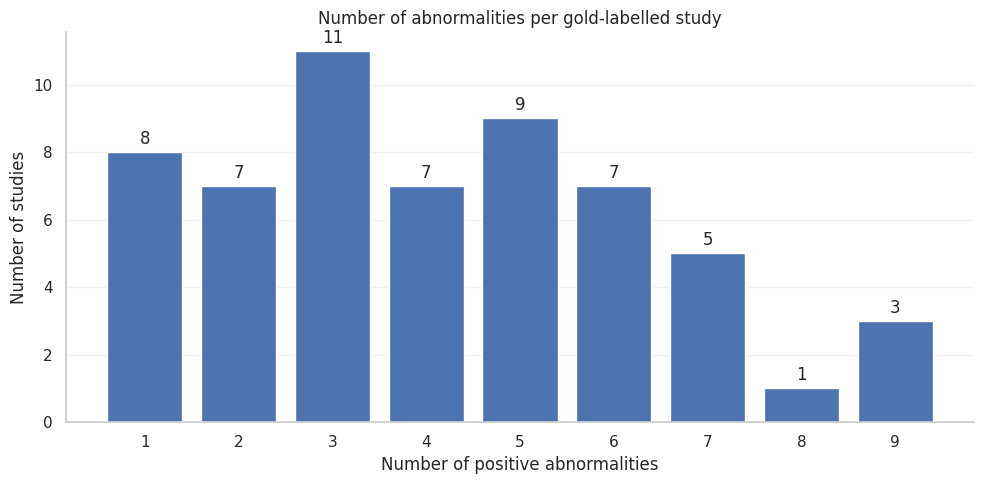

In [14]:
# 14. Notebook step
# ============================================================
# 14. Visualise positive labels per study
# ============================================================

label_count_distribution = (
    positive_labels_per_study
    .value_counts()
    .sort_index()
    .reindex(
        range(
            int(positive_labels_per_study.min()),
            int(positive_labels_per_study.max()) + 1,
        ),
        fill_value=0,
    )
    .rename_axis("positive_labels")
    .reset_index(name="number_of_studies")
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    label_count_distribution["positive_labels"],
    label_count_distribution["number_of_studies"],
    color=sns.color_palette("deep")[0],
)

ax.bar_label(bars, padding=3)

ax.set_xlabel("Number of positive abnormalities")
ax.set_ylabel("Number of studies")
ax.set_title("Number of abnormalities per gold-labelled study")
ax.set_xticks(label_count_distribution["positive_labels"])
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()


### Key findings

The gold-labelled studies contain an average of **4.14 positive abnormalities per study**, with a median of four and a range from one to nine.

Every one of the 58 studies has at least one positive target. There are no completely negative or normal studies in the gold-labelled subset.

This suggests that the gold subset is enriched for abnormal cases. It should therefore be used cautiously for estimating prevalence or validating performance on normal studies. Although every individual target has both positive and negative examples, the subset cannot directly measure how well a model distinguishes a completely normal knee from one containing any abnormality.

The high number of findings per study also confirms that this is a genuinely multi-label problem. Models must be able to identify several co-existing abnormalities rather than select a single diagnosis.

## Target co-occurrence

Some knee abnormalities may frequently appear together. The following matrix counts the number of gold-labelled studies in which each pair of targets is positive.

The diagonal represents the total number of positive cases for each individual target.

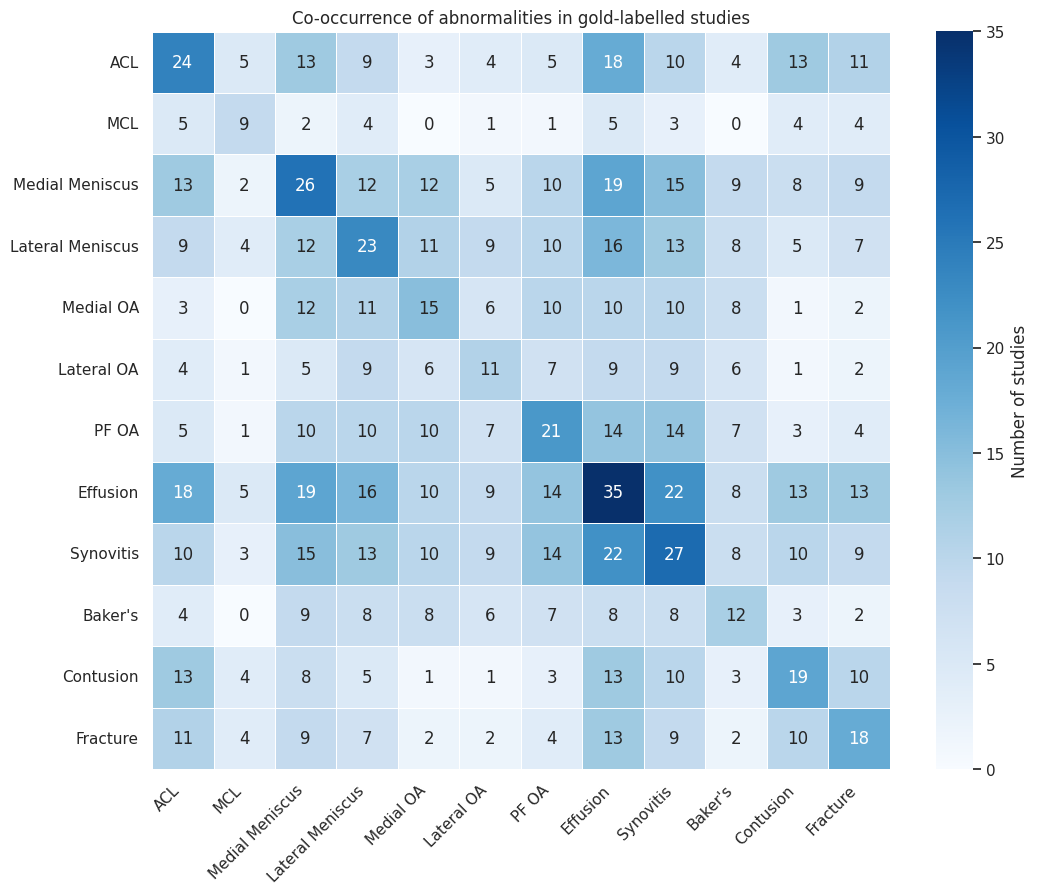

In [15]:
# 15. Notebook step
# ============================================================
# 15. Calculate target co-occurrence
# ============================================================

cooccurrence_matrix = gold_labels.T.dot(gold_labels)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    cooccurrence_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Number of studies"},
    ax=ax,
)

ax.set_title("Co-occurrence of abnormalities in gold-labelled studies")
ax.set_xlabel("")
ax.set_ylabel("")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [16]:
# 16. Notebook step
# ============================================================
# 16. Summarise the most frequent target pairs
# ============================================================

pair_rows = []

for first_index, first_target in enumerate(TARGET_COLUMNS):
    for second_target in TARGET_COLUMNS[first_index + 1:]:
        first_positive = gold_labels[first_target] == 1
        second_positive = gold_labels[second_target] == 1

        both_positive = int(
            (first_positive & second_positive).sum()
        )

        either_positive = int(
            (first_positive | second_positive).sum()
        )

        pair_rows.append({
            "first_target": first_target,
            "second_target": second_target,
            "both_positive": both_positive,
            "percentage_of_gold_studies": (
                both_positive / len(gold_labels) * 100
            ),
            "jaccard_similarity": (
                both_positive / either_positive
                if either_positive > 0
                else np.nan
            ),
        })

target_pairs = (
    pd.DataFrame(pair_rows)
    .sort_values(
        ["both_positive", "jaccard_similarity"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(target_pairs.head(15))


,first_target,second_target,both_positive,percentage_of_gold_studies,jaccard_similarity
0,Effusion,Synovitis,22,37.9310,0.5500
1,Medial Meniscus,Effusion,19,32.7586,0.4524
2,ACL,Effusion,18,31.0345,0.4390
3,Lateral Meniscus,Effusion,16,27.5862,0.3810
4,Medial Meniscus,Synovitis,15,25.8621,0.3947
5,PF OA,Synovitis,14,24.1379,0.4118
6,PF OA,Effusion,14,24.1379,0.3333
7,ACL,Contusion,13,22.4138,0.4333
8,ACL,Medial Meniscus,13,22.4138,0.3514
9,Lateral Meniscus,Synovitis,13,22.4138,0.3514


### Key findings

The strongest observed overlap is between **Effusion and Synovitis**. Both are present in 22 studies, representing 37.9% of the gold subset. Their Jaccard similarity of 0.55 means that 55% of studies containing either finding contain both.

Other frequent combinations include:

- Medial Meniscus injury with Effusion: 19 studies;
- ACL injury with Effusion: 18 studies;
- Lateral Meniscus injury with Effusion: 16 studies;
- Medial Meniscus injury with Synovitis: 15 studies; and
- PF OA with Synovitis: 14 studies.

Some less frequent targets also show notable proportional overlap. For example, ACL injury and Contusion have a Jaccard similarity of 0.43, while Medial Meniscus injury and Medial OA have a similarity of 0.41.

Raw co-occurrence counts are partly influenced by individual target prevalence. Effusion appears in many of the leading pairs because it is the most common target. The Jaccard similarity provides additional context by measuring overlap relative to how often either target occurs.

These relationships are exploratory. With only 58 studies, they should not be interpreted as precise or causal clinical associations.

# Radiology report analysis

Only 58 studies contain expert-structured target labels. For the remaining 4,349 studies, the accompanying radiology reports are the main source of supervision.

Before attempting to extract weak labels, we need to understand:

- report completeness and uniqueness;
- report length and structure;
- differences between gold-labelled and report-only studies;
- repeated or templated reports;
- the languages represented in the dataset; and
- how consistently the 12 target findings are described.

We begin with general text characteristics before examining languages and condition-specific terminology.

In [17]:
# 17. Notebook step
# ============================================================
# 17. Prepare the radiology reports
# ============================================================

report_data = train[
    [ID_COLUMN, "Report"]
].copy()

report_data["label_status"] = np.where(
    fully_labelled_mask,
    "Gold-labelled",
    "Report-only",
)

report_data["normalized_report"] = (
    report_data["Report"]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

report_data["report_characters"] = (
    report_data["Report"]
    .fillna("")
    .str.len()
)

report_data["report_words"] = (
    report_data["Report"]
    .fillna("")
    .str.split()
    .str.len()
)

report_data["report_lines"] = (
    report_data["Report"]
    .fillna("")
    .str.count("\n")
    .add(1)
)

report_data["exact_duplicate"] = (
    report_data["Report"]
    .duplicated(keep=False)
)

report_data["normalized_duplicate"] = (
    report_data["normalized_report"]
    .duplicated(keep=False)
)


## Report coverage and uniqueness

Missing or empty reports would provide no weak-supervision signal. Repeated reports may represent reporting templates, genuine duplicate text or closely related examinations.

In [18]:
# 18. Notebook step
# ============================================================
# 18. Summarise report coverage
# ============================================================

report_coverage = pd.DataFrame({
    "metric": [
        "Training studies",
        "Missing reports",
        "Empty reports",
        "Unique exact reports",
        "Unique normalized reports",
        "Rows belonging to an exact duplicate group",
        "Rows belonging to a normalized duplicate group",
    ],
    "value": [
        len(report_data),
        int(report_data["Report"].isna().sum()),
        int(report_data["normalized_report"].eq("").sum()),
        int(report_data["Report"].nunique(dropna=True)),
        int(report_data["normalized_report"].nunique()),
        int(report_data["exact_duplicate"].sum()),
        int(report_data["normalized_duplicate"].sum()),
    ],
})

display(report_coverage)


,metric,value
0,Training studies,4407
1,Missing reports,0
2,Empty reports,0
3,Unique exact reports,4276
4,Unique normalized reports,4257
5,Rows belonging to an exact duplicate group,177
6,Rows belonging to a normalized duplicate group,204


### Report availability and uniqueness findings

All 4,407 training studies have a non-empty report, meaning every report-only study has some potential source of weak supervision.

Most reports are unique. However, 177 rows belong to an exact duplicate group, increasing to 204 after differences in whitespace and capitalisation are removed. Report duplication is therefore present but affects only a small proportion of the dataset.

## Report length

Report length provides a simple indication of how much textual information is available for weak-label extraction.

We compare gold-labelled and report-only studies to check whether the small gold subset contains systematically different reports.

In [19]:
# 19. Notebook step
# ============================================================
# 19. Summarise report length
# ============================================================

def report_length_summary(group):
    return pd.Series({
        "studies": len(group),
        "mean_words": group["report_words"].mean(),
        "median_words": group["report_words"].median(),
        "q1_words": group["report_words"].quantile(0.25),
        "q3_words": group["report_words"].quantile(0.75),
        "maximum_words": group["report_words"].max(),
        "mean_characters": group["report_characters"].mean(),
        "median_characters": group["report_characters"].median(),
    })

report_length_by_status = (
    report_data
    .groupby("label_status", sort=False)
    .apply(report_length_summary, include_groups=False)
    .reset_index()
)

display(report_length_by_status)


,label_status,studies,mean_words,median_words,q1_words,q3_words,maximum_words,mean_characters,median_characters
0,Report-only,"4,349.0000",147.1235,128.0000,74.0000,201.0000,690.0000,"1,095.1426",974.0000
1,Gold-labelled,58.0000,179.0000,161.5000,98.5000,232.5000,542.0000,"1,305.0862","1,205.5000"


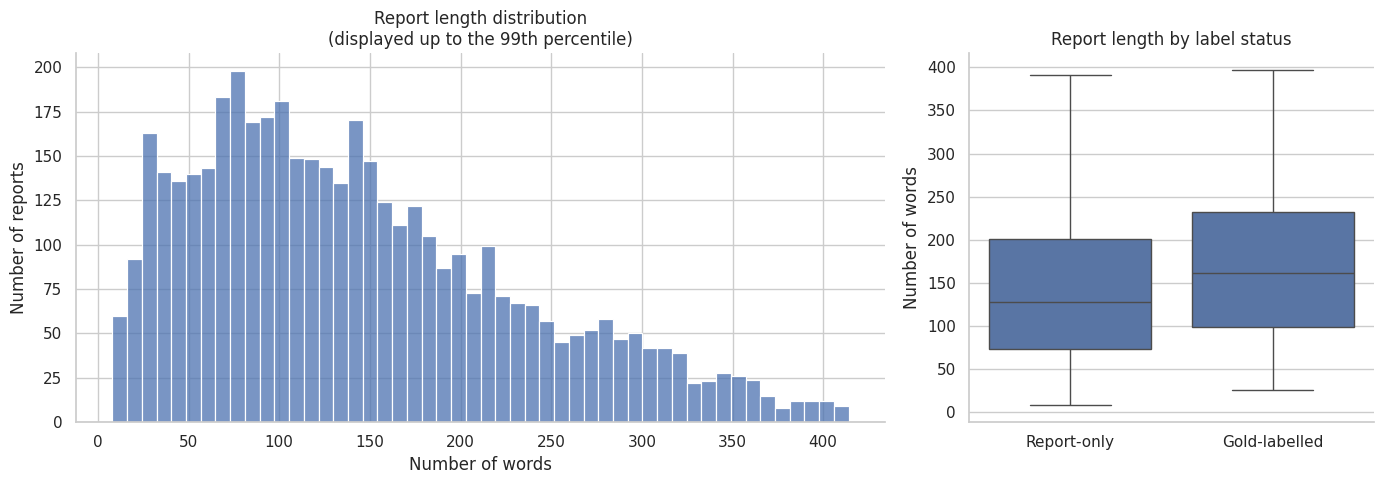

In [20]:
# 20. Notebook step
# ============================================================
# 20. Visualise report length
# ============================================================

word_limit_99 = report_data["report_words"].quantile(0.99)

plot_reports = report_data.loc[
    report_data["report_words"] <= word_limit_99
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)

sns.histplot(
    data=plot_reports,
    x="report_words",
    bins=50,
    color=sns.color_palette("deep")[0],
    ax=axes[0],
)

axes[0].set_title(
    "Report length distribution\n"
    "(displayed up to the 99th percentile)"
)
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Number of reports")

sns.boxplot(
    data=report_data,
    x="label_status",
    y="report_words",
    showfliers=False,
    color=sns.color_palette("deep")[0],
    ax=axes[1],
)

axes[1].set_title("Report length by label status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of words")

sns.despine()
plt.tight_layout()
plt.show()


### Report length Findings

Report lengths vary considerably and have a long right tail.

Gold-labelled reports are generally longer than report-only reports. Their median length is 161.5 words, compared with 128 words for report-only studies. However, the distributions overlap substantially.

This difference provides further evidence that the 58 gold-labelled studies may be a selected subset rather than a representative sample of all training studies.

In [21]:
# 21. Notebook step
# ============================================================
# 21. Inspect repeated report text
# ============================================================

duplicate_report_summary = (
    report_data
    .groupby("normalized_report")
    .agg(
        number_of_studies=(ID_COLUMN, "size"),
        gold_labelled_studies=(
            "label_status",
            lambda values: (values == "Gold-labelled").sum(),
        ),
        example_report=("Report", "first"),
    )
    .query("number_of_studies > 1")
    .sort_values("number_of_studies", ascending=False)
    .reset_index(drop=True)
)

duplicate_report_summary["report_excerpt"] = (
    duplicate_report_summary["example_report"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 250)
)

display(
    duplicate_report_summary[
        [
            "number_of_studies",
            "gold_labelled_studies",
            "report_excerpt",
        ]
    ].head(15)
)


,number_of_studies,gold_labelled_studies,report_excerpt
0,37,0,Diz eklemi içi sıvı miktarı normal. Çapraz ve ...
1,14,0,Técnica: RMN de la rodilla. Resultados: Pinzam...
2,12,0,Técnica: RMN de la rodilla. Resultados: Sin an...
3,7,0,FINDINGS: Fluid: No joint effusion. No poplite...
4,6,0,Technique: MRI of the knee. ACL normal. MCL no...
5,5,1,Technique: MRI of the knee. ACL normal. MCL no...
6,5,0,"SOL DİZ MRG. Tetkik protokolü: Çok düzlemli, ç..."
7,5,0,Técnica: RMN de la rodilla. Resultados: Sin an...
8,5,0,Técnica: RMN de la rodilla. Resultados: Síndro...
9,5,0,Técnica: RMN de la rodilla. Resultados: Rotura...


### Repeated reports

The largest repeated-report group contains 37 studies, with several smaller groups appearing in Turkish, Spanish and English.

These repetitions may represent reporting templates or genuinely duplicated text. Most of the largest groups contain no gold-labelled studies.

When validating a future report-based label extractor, studies with identical normalized reports should remain in the same fold. Otherwise, the same report text could appear in both training and validation data and produce an overly optimistic result.

## Report languages

The training reports are multilingual. This matters because terminology, negation and reporting conventions differ between languages, making report-to-label extraction more difficult.

We first estimate the language of each report. These predictions are exploratory rather than definitive, because medical terms and abbreviations can confuse general-purpose language-detection tools.

In [22]:
# 22. Notebook step
%pip install -q langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.5 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [23]:
# 23. Notebook step
# ============================================================
# 22. Detect and summarise report languages
# ============================================================

from langdetect import (
    DetectorFactory,
    LangDetectException,
    detect_langs,
)

DetectorFactory.seed = RANDOM_STATE


def detect_report_language(text):
    """Return the most likely language and estimated confidence."""
    try:
        prediction = detect_langs(text)[0]

        return pd.Series({
            "language_code": prediction.lang,
            "language_confidence": float(prediction.prob),
        })

    except LangDetectException:
        return pd.Series({
            "language_code": "unknown",
            "language_confidence": np.nan,
        })


language_predictions = (
    report_data["Report"]
    .apply(detect_report_language)
)

report_data[
    ["language_code", "language_confidence"]
] = language_predictions


LANGUAGE_NAMES = {
    "af": "Afrikaans",
    "ar": "Arabic",
    "ca": "Catalan",
    "cs": "Czech",
    "da": "Danish",
    "de": "German",
    "en": "English",
    "es": "Spanish",
    "fi": "Finnish",
    "fr": "French",
    "hu": "Hungarian",
    "it": "Italian",
    "ja": "Japanese",
    "ko": "Korean",
    "nl": "Dutch",
    "no": "Norwegian",
    "pl": "Polish",
    "pt": "Portuguese",
    "ro": "Romanian",
    "ru": "Russian",
    "sv": "Swedish",
    "tr": "Turkish",
    "uk": "Ukrainian",
    "zh-cn": "Chinese",
    "bg": "Bulgarian",
    "el": "Greek",
    "hr": "Croatian",
}

report_data["language"] = (
    report_data["language_code"]
    .map(LANGUAGE_NAMES)
    .fillna(report_data["language_code"])
)

language_summary = (
    report_data
    .groupby(
        ["language_code", "language"],
        dropna=False,
    )
    .agg(
        reports=(ID_COLUMN, "size"),
        gold_labelled_reports=(
            "label_status",
            lambda values: (values == "Gold-labelled").sum(),
        ),
        median_words=("report_words", "median"),
        mean_confidence=("language_confidence", "mean"),
    )
    .reset_index()
)

language_summary["percentage"] = (
    language_summary["reports"]
    / len(report_data)
    * 100
)

language_summary = (
    language_summary
    .sort_values("reports", ascending=False)
    .reset_index(drop=True)
)

display(language_summary)


,language_code,language,reports,gold_labelled_reports,median_words,mean_confidence,percentage
0,en,English,1736,28,181.5000,0.9997,39.3919
1,es,Spanish,682,10,103.5000,0.9969,15.4754
2,tr,Turkish,546,6,85.0000,0.9997,12.3894
3,hr,Croatian,406,4,144.0000,0.9986,9.2126
4,el,Greek,321,3,118.0000,1.0000,7.2839
5,de,German,262,2,86.0000,1.0000,5.9451
6,bg,Bulgarian,220,3,146.0000,1.0000,4.9921
7,nl,Dutch,153,2,114.0000,0.9981,3.4717
8,fr,French,81,0,215.0000,1.0000,1.8380


### Key findings

Nine languages were detected. English is the largest group with 1,736 reports (39.4%), but most reports—60.6%—are written in another language.

Spanish and Turkish are the next most common, followed by Croatian, Greek, German, Bulgarian, Dutch and French. Report length also differs by language: the median ranges from 85 words in Turkish to 215 words in French.

The 58 gold-labelled studies cover eight of the nine detected languages, but coverage is extremely limited. English has 28 gold reports, while most other languages have only two to ten. None of the 81 French reports has a gold label.

Consequently, the gold subset cannot provide a reliable language-specific evaluation of report-derived labels. In particular, French label extraction cannot be checked directly against any gold-labelled example.

The gold subset also contains a higher proportion of English reports than the full training set. Language composition may therefore explain part of the difference previously observed between gold and report-only report lengths.

### Language examples

We inspect one randomly selected report from each detected language. This provides a simple manual check that the automatic language classifications are reasonable.

In [24]:
# 24. Notebook step
# ============================================================
# 23. Preview one report from each detected language
# ============================================================

language_examples = (
    report_data
    .groupby("language", group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .copy()
)

language_examples["report_excerpt"] = (
    language_examples["Report"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 300)
)

language_examples = (
    language_examples
    .merge(
        language_summary[["language", "reports"]],
        on="language",
        how="left",
    )
    .sort_values("reports", ascending=False)
)

display(
    language_examples[
        [
            "language",
            "language_confidence",
            "label_status",
            "report_excerpt",
        ]
    ].reset_index(drop=True)
)


,language,language_confidence,label_status,report_excerpt
0,English,1.0000,Report-only,"MRI of left Knee with -Locator, SG PD FatSat, ..."
1,Spanish,1.0000,Report-only,Antecedentes Clínicos: Meniscopatía interna. [...
2,Turkish,1.0000,Report-only,Diz eklemi içi sıvı miktarı hafif derecede art...
3,Croatian,1.0000,Report-only,Prikazane koštane strukture primjerenih intenz...
4,Greek,1.0000,Report-only,MRI ΑΡ ΓΟΝΑΤΟΣ ΤΕΧΝΙΚΗ Η εξέταση έγινε με ακολ...
5,German,1.0000,Report-only,Keine Fraktur. Kreuzbänder intakt. Innenbänder...
6,Bulgarian,1.0000,Report-only,МР находка: Няма МР данни за ставен излив. Кос...
7,Dutch,1.0000,Report-only,[DATE]: MR Knie Links 15ch AA: Klinische inlic...
8,French,1.0000,Report-only,Des coupes axiales coronales et sagittales ont...


### Language detection check

The sampled excerpts are consistent with their predicted languages, so automatic language detection appears suitable for descriptive EDA. The detector's confidence values are not calibrated measures of classification accuracy, and the predictions should not be treated as definitive ground truth—particularly for medical abbreviations or closely related languages.

The language diversity confirms that weak-label extraction must be multilingual. Report terminology and negation cannot safely be handled using an English-only keyword system.


## Report structure

Radiology reports may contain separate sections for technique, findings and conclusions. These sections could help a future label extractor distinguish clinically important conclusions from background information.

We begin with language-independent structural indicators: line breaks, colons and short heading-like lines. These are simple heuristics rather than definitive section labels.

In [25]:
# 25. Notebook step
# ============================================================
# 24. Summarise report structure
# ============================================================

def contains_heading_like_line(text):
    """
    Identify short lines that resemble headings.

    A line is considered heading-like if it ends with a colon,
    or if it is a short uppercase line.
    """
    for line in str(text).splitlines():
        line = line.strip()

        if not line:
            continue

        ends_with_colon = (
            len(line) <= 80
            and line.endswith(":")
        )

        short_uppercase_line = (
            3 <= len(line) <= 80
            and len(line.split()) <= 8
            and line.isupper()
        )

        if ends_with_colon or short_uppercase_line:
            return True

    return False


report_data["has_line_break"] = (
    report_data["Report"].str.contains("\n", regex=False)
)

report_data["colon_count"] = (
    report_data["Report"].str.count(":")
)

report_data["has_heading_like_line"] = (
    report_data["Report"].apply(contains_heading_like_line)
)


structure_summary = (
    report_data
    .groupby("language")
    .agg(
        reports=(ID_COLUMN, "size"),
        median_lines=("report_lines", "median"),
        reports_with_line_breaks=("has_line_break", "mean"),
        reports_with_colons=("colon_count", lambda values: (values > 0).mean()),
        median_colons=("colon_count", "median"),
        reports_with_heading_like_lines=("has_heading_like_line", "mean"),
    )
    .reset_index()
)

percentage_columns = [
    "reports_with_line_breaks",
    "reports_with_colons",
    "reports_with_heading_like_lines",
]

structure_summary[percentage_columns] *= 100

structure_summary = (
    structure_summary
    .sort_values("reports", ascending=False)
    .reset_index(drop=True)
)

display(structure_summary)


,language,reports,median_lines,reports_with_line_breaks,reports_with_colons,median_colons,reports_with_heading_like_lines
0,English,1736,19.0000,84.1014,86.1751,2.0000,48.9055
1,Spanish,682,14.0000,51.0264,100.0000,3.0000,51.1730
2,Turkish,546,1.0000,0.0000,67.7656,2.0000,0.0000
3,Croatian,406,18.0000,99.5074,0.4926,0.0000,0.2463
4,Greek,321,1.0000,7.4766,72.2741,1.0000,0.0000
5,German,262,2.0000,52.6718,30.5344,0.0000,26.7176
6,Bulgarian,220,1.0000,25.4545,99.5455,2.0000,0.0000
7,Dutch,153,1.0000,0.0000,100.0000,6.0000,0.0000
8,French,81,29.0000,100.0000,100.0000,2.0000,100.0000


### Observation — report formatting varies by language

Report structure differs substantially across languages. French reports are consistently multi-line and section-like, while Turkish and Dutch reports are almost entirely single-line despite frequently containing colons. Croatian reports use many line breaks but almost no colons.

These differences likely reflect reporting templates and institutions as well as language. A single rule-based section parser would therefore be unreliable across the dataset; future report processing should account for language-specific formatting.

### Common report headings

The previous summary showed large formatting differences between languages. We now inspect the most frequently detected heading-like lines to understand what those structural indicators represent.

In [26]:
# 26. Inspect common heading-like lines

heading_rows = []

for language, report in report_data[["language", "Report"]].itertuples(index=False):
    for line in str(report).splitlines():
        line = " ".join(line.split())

        if not line:
            continue

        ends_with_colon = len(line) <= 80 and line.endswith(":")
        short_uppercase_line = (
            3 <= len(line) <= 80
            and len(line.split()) <= 8
            and line.isupper()
        )

        if ends_with_colon or short_uppercase_line:
            heading_rows.append({
                "language": language,
                "heading": line,
                "normalized_heading": line.casefold(),
            })

heading_data = pd.DataFrame(heading_rows)

common_headings = (
    heading_data
    .groupby(["language", "normalized_heading"], as_index=False)
    .agg(
        occurrences=("heading", "size"),
        example=("heading", "first"),
    )
    .sort_values(
        ["language", "occurrences"],
        ascending=[True, False],
    )
    .groupby("language", group_keys=False)
    .head(5)
    .drop(columns="normalized_heading")
    .reset_index(drop=True)
)

display(common_headings)


,language,occurrences,example
0,Croatian,1,Prati se bez bitnije promjene:
1,English,631,Impression:
2,English,536,Findings:
3,English,356,TECHNIQUE:
4,English,354,MEDIAL COMPARTMENT:
5,English,353,LATERAL COMPARTMENT:
6,French,65,CONCLUSION :
7,French,28,CONSTATATIONS :
8,French,24,Alignement articulaire :
9,French,24,Autres trouvailles significatives :


### Observation — headings are useful but language-dependent

The heuristic identifies genuine recurring sections in English, Spanish, French and German, including Findings, Impression and Conclusion. These sections may be particularly useful because the final diagnostic summary is often more concise than the full report.

However, several languages produce no common headings, and entries such as [DATE]. show that the heuristic can generate false positives. Section-aware extraction could therefore help for some report templates, but it should not be required for every report.

## Reports and gold labels

The 58 fully labelled studies provide the only direct evidence of how the radiology reports relate to the competition targets. We begin by placing each gold-labelled report beside its positive targets.

The examples below are qualitative rather than a test of report–label agreement. A diagnosis may be expressed using synonyms, abbreviations or negation, and many reports contain several positive targets.

In [27]:
# 27. Link gold labels to their reports

gold_report_data = (
    report_data.loc[
        report_data["label_status"] == "Gold-labelled"
    ]
    .merge(
        train[[ID_COLUMN] + TARGET_COLUMNS],
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

gold_report_data["positive_targets"] = (
    gold_report_data[TARGET_COLUMNS]
    .apply(
        lambda row: ", ".join(
            target
            for target in TARGET_COLUMNS
            if row[target] == 1
        ),
        axis=1,
    )
)

def create_report_excerpt(report, maximum_characters=400):
    clean_report = " ".join(str(report).split())

    if len(clean_report) <= maximum_characters:
        return clean_report

    excerpt_length = (maximum_characters - 5) // 2

    return (
        clean_report[:excerpt_length]
        + " ... "
        + clean_report[-excerpt_length:]
    )

gold_report_data["report_excerpt"] = (
    gold_report_data["Report"]
    .apply(create_report_excerpt)
)

gold_report_examples = (
    gold_report_data
    .groupby("language", group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .sort_values("language")
    [["language", "positive_targets", "report_excerpt"]]
    .reset_index(drop=True)
)

display(gold_report_examples)


,language,positive_targets,report_excerpt
0,Bulgarian,Fracture,МР находка: МР данни за фрактура на тибията в ...
1,Croatian,"Medial Meniscus, Medial OA, Effusion, Synoviti...","Koštani edem medijalnog kondila femura, anteri..."
2,Dutch,"ACL, Medial Meniscus, Lateral Meniscus, Medial...",[DATE]: MR Knie Rechts 15ch AA: Klinische inli...
3,English,"ACL, Contusion, Fracture",No evidence of knee effusion. Normal medial an...
4,German,"Medial Meniscus, PF OA, Effusion, Synovitis",T2-hyperintense lineare radiale Läsion der Par...
5,Greek,"Medial Meniscus, Lateral Meniscus, Medial OA, ...",ΤΕΧΝΙΚΗ Η εξέταση έγινε µε ακολουθίες παλµών Τ...
6,Spanish,"ACL, Lateral Meniscus, Lateral OA, Effusion",Antecedentes Clínicos: Rodilla traumática agud...
7,Turkish,"Medial Meniscus, Lateral Meniscus, Medial OA, ...","SAĞ DİZ MRG. Tetkik protokolü: Çok düzlemli, ç..."


### Observation — gold-labelled reports are multilingual and multi-label

The gold-labelled examples span eight languages, and most reports correspond to several positive targets rather than one isolated diagnosis. The report extractor must therefore identify multiple findings while distinguishing positive diagnoses from normal or explicitly negative statements elsewhere in the same report.

French is absent because none of the 81 French reports has gold labels. Consequently, extraction quality for French cannot be measured directly using the provided labelled subset.

### Gold target coverage by report language

The gold labels are the only direct reference for evaluating labels extracted from the reports. We count the positive examples available for each target within each report language.

The heatmap shows raw counts rather than percentages because the language groups are small and vary greatly in size.

,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
report_language,,,,,,,,,,,,
English (n=28),11,5,12,11,7,6,8,15,10,5,10,8
Spanish (n=10),2,2,0,5,1,3,6,5,4,0,0,1
Turkish (n=6),4,0,5,2,1,0,1,5,3,1,2,4
Croatian (n=4),1,0,3,1,3,1,2,2,2,2,1,1
Bulgarian (n=3),2,0,1,0,0,0,1,2,1,1,2,2
Greek (n=3),1,1,2,2,2,0,1,3,3,1,2,1
Dutch (n=2),2,1,1,2,1,1,1,2,2,1,1,0
German (n=2),1,0,2,0,0,0,1,1,2,1,1,1


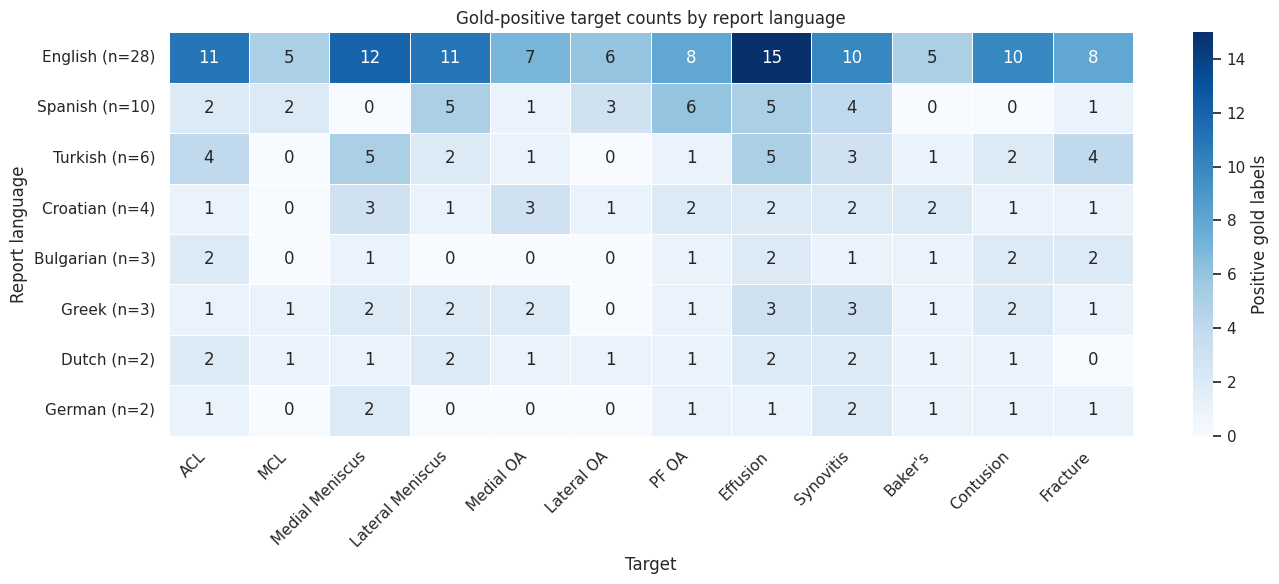

In [28]:
# 28. Count gold-positive targets within each report language

language_sample_sizes = (
    gold_report_data["language"]
    .value_counts()
)

language_order = language_sample_sizes.index

gold_target_language_counts = (
    gold_report_data
    .groupby("language")[TARGET_COLUMNS]
    .sum()
    .astype(int)
    .loc[language_order]
)

gold_target_language_counts.index = [
    f"{language} (n={language_sample_sizes[language]})"
    for language in gold_target_language_counts.index
]

gold_target_language_counts.index.name = "report_language"

display(gold_target_language_counts)

plt.figure(figsize=(14, 6))

sns.heatmap(
    gold_target_language_counts,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Positive gold labels"},
)

plt.title("Gold-positive target counts by report language")
plt.xlabel("Target")
plt.ylabel("Report language")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Observation — per-language gold coverage is extremely limited

English is the only language with at least one positive example for every target, but even there the positive counts range from only 5 to 15. The non-English language groups contain between 2 and 10 gold-labelled reports, leaving many language–target combinations with no positive examples.

A zero in this heatmap does not mean that an abnormality is absent from that language group generally; it only means that it is absent from the very small gold sample. Reliable target-specific evaluation within individual languages is therefore not possible, and French cannot be evaluated at all.

### Why keyword matching is insufficient: fracture

A report containing the word *fracture* is not necessarily fracture-positive. For example, the report may state that there is “no fracture.”

Using the English gold-labelled reports, we compare literal fracture-term mentions with the actual fracture label and inspect several examples. This is a diagnostic illustration, not a label-extraction method.

In [29]:
# 29. Audit literal fracture mentions in English gold-labelled reports

import re

FRACTURE_PATTERN = r"\bfractur\w*"

english_gold_reports = (
    gold_report_data.loc[
        gold_report_data["language"] == "English"
    ]
    .copy()
)

english_gold_reports["fracture_term_present"] = (
    english_gold_reports["Report"]
    .str.contains(
        FRACTURE_PATTERN,
        case=False,
        regex=True,
        na=False,
    )
)

fracture_mention_table = pd.crosstab(
    english_gold_reports["Fracture"].map({
        0: "Gold negative",
        1: "Gold positive",
    }),
    english_gold_reports["fracture_term_present"].map({
        False: "Term absent",
        True: "Term present",
    }),
    margins=True,
)

display(fracture_mention_table)

def extract_term_context(report, pattern, context_characters=120):
    clean_report = " ".join(str(report).split())
    match = re.search(pattern, clean_report, flags=re.IGNORECASE)

    if match is None:
        return "[term not present]"

    start = max(0, match.start() - context_characters)
    end = min(
        len(clean_report),
        match.end() + context_characters,
    )

    prefix = "..." if start > 0 else ""
    suffix = "..." if end < len(clean_report) else ""

    return prefix + clean_report[start:end] + suffix

english_gold_reports["fracture_context"] = (
    english_gold_reports["Report"]
    .apply(
        lambda report: extract_term_context(
            report,
            FRACTURE_PATTERN,
        )
    )
)

fracture_examples = pd.concat([
    english_gold_reports.loc[
        (english_gold_reports["Fracture"] == 1)
        & english_gold_reports["fracture_term_present"]
    ].sort_values(ID_COLUMN).head(3),

    english_gold_reports.loc[
        (english_gold_reports["Fracture"] == 0)
        & english_gold_reports["fracture_term_present"]
    ].sort_values(ID_COLUMN).head(3),
])

fracture_examples["gold_fracture_label"] = (
    fracture_examples["Fracture"]
    .map({
        0: "Negative",
        1: "Positive",
    })
)

display(
    fracture_examples[
        [
            "gold_fracture_label",
            "positive_targets",
            "fracture_context",
        ]
    ].reset_index(drop=True)
)


fracture_term_present,Term absent,Term present,All
Fracture,,,
Gold negative,13,7,20
Gold positive,1,7,8
All,14,14,28


,gold_fracture_label,positive_targets,fracture_context
0,Positive,"Medial Meniscus, Lateral Meniscus, Medial OA, ...",... using a standard non-contrast protocol. FI...
1,Positive,"Lateral Meniscus, Fracture","> MRI of knee was performed in sagittal, axial..."
2,Positive,"Medial Meniscus, Lateral Meniscus, Medial OA, ...",... tear. Lateral meniscus tear. Incipient OA ...
3,Negative,"Lateral Meniscus, PF OA, Synovitis",The study reveals normal knee joint alignment....
4,Negative,"Medial Meniscus, Medial OA, PF OA, Synovitis","...al, and coronal), using a standard non-cont..."
5,Negative,"ACL, Medial Meniscus",...tact. The extensor mechanism is normal. No ...


### Observation — mentioning fracture is not the same as diagnosing it

The fracture term appears in 7 of 8 fracture-positive English reports, but it also appears in 7 of 20 fracture-negative reports. If literal term presence were treated as a positive prediction, only half of the 14 predicted positives would be correct.

One gold-positive report also does not contain the searched fracture term, showing that keyword matching can miss alternative wording. A useful report extractor must therefore handle both negation and linguistic variation rather than relying on term presence alone.

## Language composition by label availability

Because the gold-labelled subset is very small, we compare its language composition with the report-only data. Large differences would be another reason not to treat the gold subset as representative of the full training set.


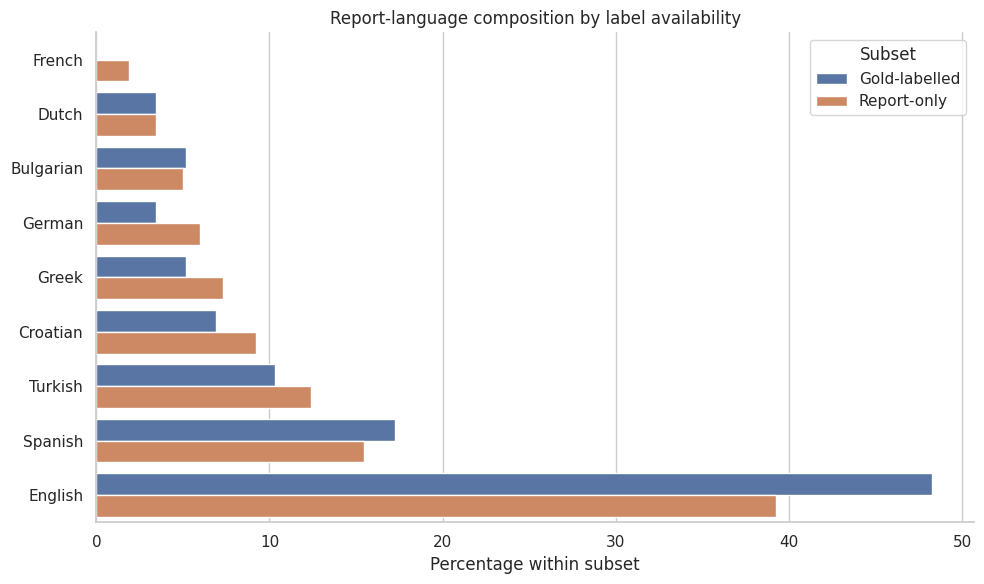

label_status,Gold-labelled,Report-only
language,,
English,28,1708
Spanish,10,672
Turkish,6,540
Croatian,4,402
Greek,3,318
German,2,260
Bulgarian,3,217
Dutch,2,151
French,0,81


In [30]:
# 30. Compare report-language composition by label availability

language_status_counts = pd.crosstab(
    report_data["language"],
    report_data["label_status"],
)

language_status_percent = (
    language_status_counts
    .div(language_status_counts.sum(axis=0), axis=1)
    .mul(100)
)

language_status_plot = (
    language_status_percent
    .reset_index()
    .melt(
        id_vars="language",
        var_name="label_status",
        value_name="percentage_within_status",
    )
)

language_order = (
    language_status_counts.sum(axis=1)
    .sort_values(ascending=True)
    .index
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=language_status_plot,
    x="percentage_within_status",
    y="language",
    hue="label_status",
    order=language_order,
    ax=ax,
)

ax.set_title("Report-language composition by label availability")
ax.set_xlabel("Percentage within subset")
ax.set_ylabel("")
ax.legend(title="Subset")

sns.despine()
plt.tight_layout()
plt.show()

display(language_status_counts.loc[language_order[::-1]])


### Observation — the gold subset has a different language mix

The chart compares percentages within each subset rather than raw counts. The gold-labelled sample contains a larger share of English reports and no French reports, while several non-English groups contain only a handful of gold examples.

Language and label availability are therefore associated in the visible training data. This reinforces the need for multilingual extraction and cautions against assuming that report-extractor performance on the gold subset transfers uniformly to all report-only studies.


## Report analysis conclusion

All training studies have non-empty reports, so the full training set provides potential text-based information. The reports are multilingual and their structure varies by language, while repeated templates appear in a small subset.

The 58 gold-labelled reports cover only eight languages and provide limited target-specific examples, with no French-labelled studies. Reports can therefore support weak supervision, but report-based labels will require language-aware processing and careful validation against the small gold subset.

# MRI series metadata

Each study may contain several MRI series acquired using different planes and sequence settings. We first examine how many series are available per study.

In [31]:
# 31. Summarise the number of MRI series per study

series_count_rows = []

for split_name, series_table in {
    "Train": train_series,
    "Test": test_series,
}.items():
    series_per_study = (
        series_table
        .groupby(ID_COLUMN)["SeriesInstanceUID"]
        .nunique()
    )

    series_count_rows.append({
        "split": split_name,
        "studies": series_per_study.size,
        "total_series": series_per_study.sum(),
        "minimum": series_per_study.min(),
        "q1": series_per_study.quantile(0.25),
        "median": series_per_study.median(),
        "mean": series_per_study.mean(),
        "q3": series_per_study.quantile(0.75),
        "maximum": series_per_study.max(),
    })

series_count_summary = pd.DataFrame(series_count_rows)

display(series_count_summary)


,split,studies,total_series,minimum,q1,median,mean,q3,maximum
0,Train,4407,24371,3,5.0000,5.0000,5.5301,6.0000,14
1,Test,3,15,5,5.0000,5.0000,5.0000,5.0000,5


## Distribution of series counts

The summary table describes the number of MRI series per study. A bar chart makes it easier to see whether most studies use the same number of series or whether the distribution is highly variable.

,number_of_series,number_of_studies
0,3,1
1,4,675
2,5,2299
3,6,698
4,7,310
5,8,145
6,9,176
7,10,74
8,11,21
9,12,5


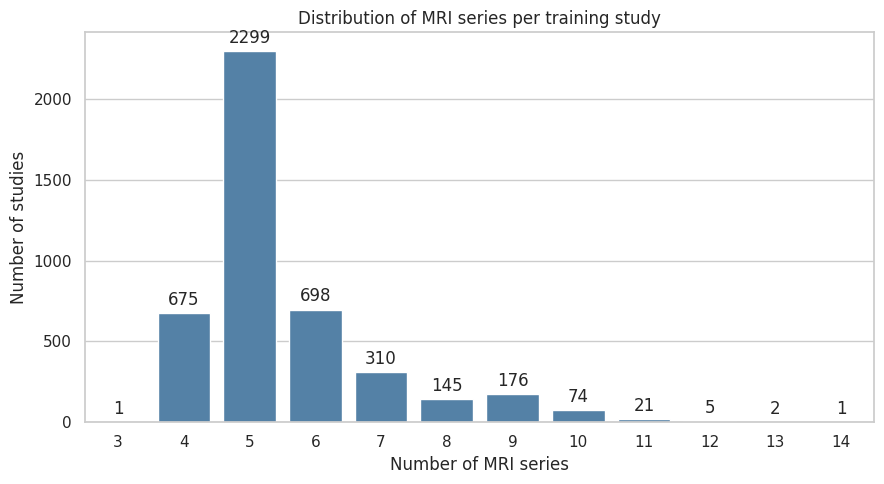

In [32]:
# 32. Visualise the number of series per training study

train_series_per_study = (
    train_series
    .groupby(ID_COLUMN)["SeriesInstanceUID"]
    .nunique()
)

series_count_distribution = (
    train_series_per_study
    .value_counts()
    .sort_index()
    .rename_axis("number_of_series")
    .reset_index(name="number_of_studies")
)

display(series_count_distribution)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=series_count_distribution,
    x="number_of_series",
    y="number_of_studies",
    color="steelblue",
    errorbar=None,
)

ax.bar_label(ax.containers[0], fmt="%d", padding=3)

plt.title("Distribution of MRI series per training study")
plt.xlabel("Number of MRI series")
plt.ylabel("Number of studies")
plt.tight_layout()
plt.show()


### Observation — five series is the dominant study structure

Five MRI series is the most common configuration, occurring in 2,299 studies, or approximately 52% of the training set. Most studies contain between four and six series, but the number ranges from three to fourteen.

This variation suggests that some studies contain additional sequences or acquisitions. A future model should therefore handle a variable number of series rather than assuming that every study has exactly five.

## Anatomical plane

MRI sequences can be acquired in different anatomical planes. These planes provide different views of the knee and may contain complementary information for abnormality detection.

,anatomical_plane,number_of_series,percentage
0,Sagittal,9864,40.4743
1,Coronal,8609,35.3248
2,Axial,5898,24.2009


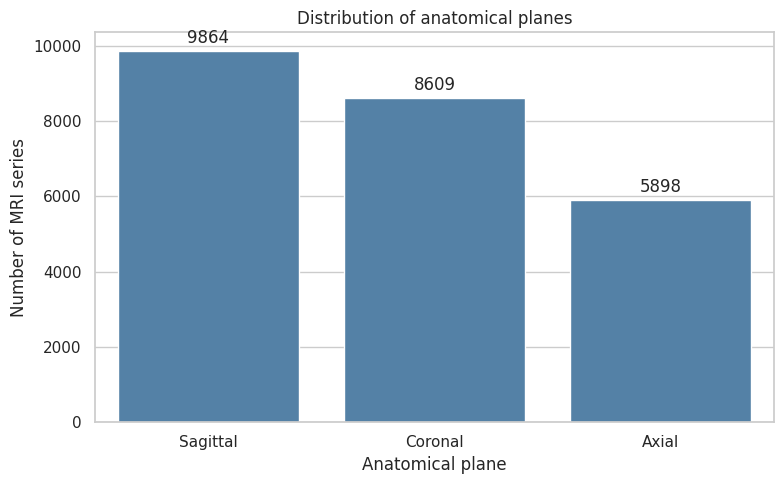

In [33]:
# 33. Distribution of anatomical planes

plane_distribution = (
    train_series["Anatomical_Plane"]
    .value_counts(dropna=False)
    .rename_axis("anatomical_plane")
    .reset_index(name="number_of_series")
)

plane_distribution["percentage"] = (
    plane_distribution["number_of_series"]
    / len(train_series)
    * 100
)

display(plane_distribution)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plane_distribution,
    x="anatomical_plane",
    y="number_of_series",
    color="steelblue",
    errorbar=None,
)

ax.bar_label(ax.containers[0], fmt="%d", padding=3)

plt.title("Distribution of anatomical planes")
plt.xlabel("Anatomical plane")
plt.ylabel("Number of MRI series")
plt.tight_layout()
plt.show()


### Observation — sagittal and coronal series are most common

Sagittal series account for approximately 40% of all training series, followed by coronal series at 35% and axial series at 24%. The dataset therefore provides multiple complementary views of the knee, although axial imaging is somewhat less frequent.

These are series-level percentages, so studies containing more series contribute more heavily to the totals. We should also examine the plane distribution at the study level before drawing conclusions about individual examinations.

### Anatomical planes per study

A series-level distribution can be influenced by studies with many MRI series. Here we calculate the percentage of studies containing at least one series from each anatomical plane.

In [34]:
# 34. Anatomical plane coverage across studies

study_plane_presence = pd.crosstab(
    train_series[ID_COLUMN],
    train_series["Anatomical_Plane"],
).gt(0)

study_plane_presence = study_plane_presence.reindex(
    columns=["Sagittal", "Coronal", "Axial"],
    fill_value=False,
)

plane_study_summary = (
    study_plane_presence
    .sum()
    .rename("number_of_studies")
    .reset_index()
    .rename(columns={"Anatomical_Plane": "anatomical_plane"})
)

plane_study_summary["percentage_of_studies"] = (
    plane_study_summary["number_of_studies"]
    / len(study_plane_presence)
    * 100
)

display(plane_study_summary)


,anatomical_plane,number_of_studies,percentage_of_studies
0,Sagittal,4407,100.0000
1,Coronal,4407,100.0000
2,Axial,4407,100.0000


### Observation — every study contains all three anatomical planes

Every training study contains at least one sagittal, coronal and axial series. Therefore, the lower number of axial series does not mean that axial imaging is missing from some studies; it means that studies generally contain fewer axial series than sagittal or coronal series.

## Sequence properties 

The series table also records whether each series is fluid-sensitive and whether fat suppression was used. These properties describe how the MRI sequence was acquired and may help distinguish the most informative series for each abnormality.

In [35]:
# 35. Distribution of sequence properties

sequence_properties = ["Fluid_Sensitive", "Fat_Suppression"]

sequence_property_rows = []

for property_name in sequence_properties:
    value_counts = (
        train_series[property_name]
        .value_counts(dropna=False)
        .sort_index()
    )

    for value, count in value_counts.items():
        sequence_property_rows.append({
            "property": property_name,
            "value": value,
            "number_of_series": count,
            "percentage": count / len(train_series) * 100,
        })

sequence_property_summary = pd.DataFrame(sequence_property_rows)

display(sequence_property_summary)


,property,value,number_of_series,percentage
0,Fluid_Sensitive,0,10361,42.5136
1,Fluid_Sensitive,1,14010,57.4864
2,Fat_Suppression,0,10361,42.5136
3,Fat_Suppression,1,14010,57.4864


### Observation — the two sequence flags have identical distributions

Both `Fluid_Sensitive` and `Fat_Suppression` have exactly the same distribution: approximately 57.5% of series have value `1` and 42.5% have value `0`.

This may indicate that the two properties are perfectly aligned in this dataset. If so, they would be redundant features, although we should verify their row-by-row relationship before drawing that conclusion.

### Relationship between the two sequence flags

Identical marginal distributions do not necessarily mean that two variables are identical row by row. We therefore compare the two flags directly.

In [36]:
# 36. Compare Fluid_Sensitive and Fat_Suppression row by row

flag_crosstab = pd.crosstab(
    train_series["Fluid_Sensitive"],
    train_series["Fat_Suppression"],
    margins=True,
)

flag_crosstab.index.name = "Fluid_Sensitive"
flag_crosstab.columns.name = "Fat_Suppression"

display(flag_crosstab)

number_of_mismatches = (
    train_series["Fluid_Sensitive"]
    != train_series["Fat_Suppression"]
).sum()

agreement_percentage = (
    1 - number_of_mismatches / len(train_series)
) * 100

print(f"Number of mismatched series: {number_of_mismatches:,}")
print(f"Percentage of series in agreement: {agreement_percentage:.2f}%")


Fat_Suppression,0,1,All
Fluid_Sensitive,,,
0,10361,0,10361
1,0,14010,14010
All,10361,14010,24371


Number of mismatched series: 0
Percentage of series in agreement: 100.00%


### Observation — the sequence flags are duplicates

`Fluid_Sensitive` and `Fat_Suppression` agree for all 24,371 training series. Every series with value `0` for one flag also has value `0` for the other, and the same is true for value `1`.

These columns therefore contain no independent information. For modelling, one of them can be removed without losing information. We will retain both in the raw-data description but should avoid treating them as two separate predictors.

### Sequence properties by anatomical plane

The usefulness of a sequence depends on both its anatomical plane and its acquisition properties. We therefore examine how the fluid-sensitive flag is distributed within each plane.

,Anatomical_Plane,Fluid_Sensitive,number_of_series,percentage_within_plane,sequence_type
0,Axial,0,1179,19.9898,Not fluid-sensitive
1,Axial,1,4719,80.0102,Fluid-sensitive
2,Coronal,0,3985,46.2888,Not fluid-sensitive
3,Coronal,1,4624,53.7112,Fluid-sensitive
4,Sagittal,0,5197,52.6865,Not fluid-sensitive
5,Sagittal,1,4667,47.3135,Fluid-sensitive


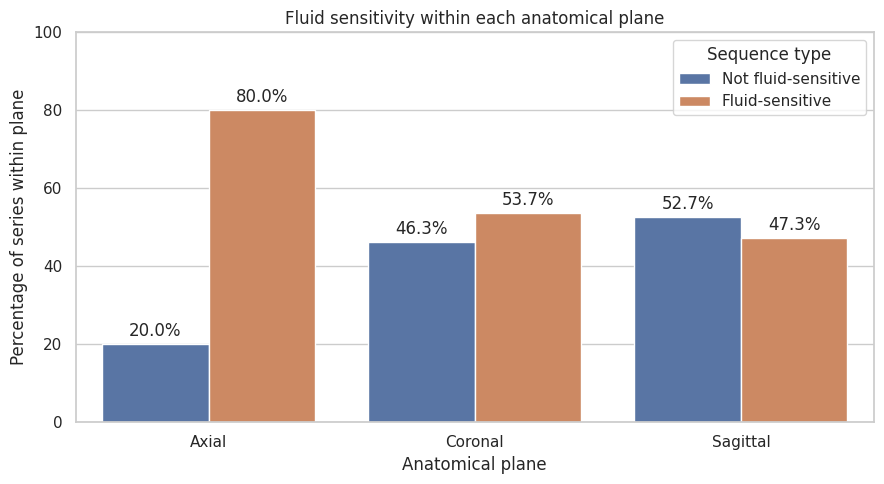

In [37]:
# 37. Compare fluid sensitivity across anatomical planes

plane_sequence_summary = (
    train_series
    .groupby(
        ["Anatomical_Plane", "Fluid_Sensitive"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "number_of_series"})
)

plane_sequence_summary["percentage_within_plane"] = (
    plane_sequence_summary["number_of_series"]
    / plane_sequence_summary.groupby("Anatomical_Plane")[
        "number_of_series"
    ].transform("sum")
    * 100
)

plane_sequence_summary["sequence_type"] = (
    plane_sequence_summary["Fluid_Sensitive"]
    .map({
        0: "Not fluid-sensitive",
        1: "Fluid-sensitive",
    })
)

display(plane_sequence_summary)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plane_sequence_summary,
    x="Anatomical_Plane",
    y="percentage_within_plane",
    hue="sequence_type",
    errorbar=None,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.ylim(0, 100)
plt.title("Fluid sensitivity within each anatomical plane")
plt.xlabel("Anatomical plane")
plt.ylabel("Percentage of series within plane")
plt.legend(title="Sequence type")
plt.tight_layout()
plt.show()


### Observation — sequence properties vary by anatomical plane

Fluid-sensitive sequences are especially common in the axial plane, where they account for 80% of series. The split is much more even for coronal and sagittal series.

Anatomical plane and sequence type are therefore related rather than independent metadata fields. A future imaging model may benefit from distinguishing these plane–sequence combinations when selecting or combining series.

# Study–series data integrity

The competition contains separate study-level and series-level tables. Before examining image files, we verify that their identifiers are unique, that every series belongs to the expected split, and that training and test identifiers do not overlap.

These checks are important because accidental identifier duplication or overlap could cause incorrect joins or data leakage.

In [38]:
# 38. Validate study and series identifiers

def add_integrity_check(check_name, value, expected=0):
    return {
        "check": check_name,
        "value": int(value),
        "status": "PASS" if int(value) == expected else "CHECK",
    }

train_study_ids = set(train[ID_COLUMN].dropna())
test_study_ids = set(test[ID_COLUMN].dropna())

train_series_study_ids = set(
    train_series[ID_COLUMN].dropna()
)
test_series_study_ids = set(
    test_series[ID_COLUMN].dropna()
)

train_series_ids = set(
    train_series["SeriesInstanceUID"].dropna()
)
test_series_ids = set(
    test_series["SeriesInstanceUID"].dropna()
)

series_to_study_counts = (
    train_series
    .groupby("SeriesInstanceUID")[ID_COLUMN]
    .nunique()
)

integrity_checks = [
    add_integrity_check(
        "Duplicate training study IDs",
        train[ID_COLUMN].duplicated().sum(),
    ),
    add_integrity_check(
        "Duplicate test study IDs",
        test[ID_COLUMN].duplicated().sum(),
    ),
    add_integrity_check(
        "Duplicate training series IDs",
        train_series["SeriesInstanceUID"].duplicated().sum(),
    ),
    add_integrity_check(
        "Duplicate test series IDs",
        test_series["SeriesInstanceUID"].duplicated().sum(),
    ),
    add_integrity_check(
        "Training studies missing from train_series",
        len(train_study_ids - train_series_study_ids),
    ),
    add_integrity_check(
        "Unknown studies in train_series",
        len(train_series_study_ids - train_study_ids),
    ),
    add_integrity_check(
        "Test studies missing from test_series",
        len(test_study_ids - test_series_study_ids),
    ),
    add_integrity_check(
        "Unknown studies in test_series",
        len(test_series_study_ids - test_study_ids),
    ),
    add_integrity_check(
        "Study IDs shared by train and test",
        len(train_study_ids & test_study_ids),
    ),
    add_integrity_check(
        "Series IDs shared by train and test",
        len(train_series_ids & test_series_ids),
    ),
    add_integrity_check(
        "Series IDs assigned to multiple studies",
        (series_to_study_counts > 1).sum(),
    ),
]

integrity_summary = pd.DataFrame(integrity_checks)

display(integrity_summary)


,check,value,status
0,Duplicate training study IDs,0,PASS
1,Duplicate test study IDs,0,PASS
2,Duplicate training series IDs,0,PASS
3,Duplicate test series IDs,0,PASS
4,Training studies missing from train_series,0,PASS
5,Unknown studies in train_series,0,PASS
6,Test studies missing from test_series,0,PASS
7,Unknown studies in test_series,0,PASS
8,Study IDs shared by train and test,0,PASS
9,Series IDs shared by train and test,0,PASS


### Observation — the study and series tables join cleanly

All study- and series-level identifier checks passed. The tables therefore form a clean relational structure for joining study-level labels, series metadata and image directories.

These checks do not establish patient-level independence and do not rule out visually similar or duplicated examinations. Patient-grouping feasibility is examined next.


## Patient-level grouping feasibility

Study identifiers keep slices and series from the same examination together, but one patient may have more than one study. We inspect anonymised `PatientID` availability for the 58 gold-labelled studies without displaying the identifier values themselves.

The resulting hashes are used only to count repeated groups. If identifiers are missing, constant or unsuitable, patient-level independence cannot be established from this dataset.


In [39]:
# 39. Inspect anonymised patient grouping among gold-labelled studies

import hashlib
import pydicom

patient_group_rows = []
gold_patient_study_ids = set(labelled_train[ID_COLUMN])
patient_image_root = COMPETITION_ROOT / "train_series"

for study_uid in sorted(gold_patient_study_ids):
    study_series_rows = train_series.loc[
        train_series[ID_COLUMN] == study_uid,
        "SeriesInstanceUID",
    ]
    series_uid = study_series_rows.iloc[0]
    series_path = patient_image_root / study_uid / series_uid

    dicom_paths = sorted(
        Path(entry.path)
        for entry in os.scandir(series_path)
        if entry.is_file(follow_symlinks=False)
        and Path(entry.name).suffix.lower() == ".dcm"
    )

    patient_identifier = ""
    error = None

    try:
        if not dicom_paths:
            raise FileNotFoundError("No DICOM files found")

        dataset = pydicom.dcmread(
            dicom_paths[0],
            stop_before_pixels=True,
            specific_tags=["PatientID"],
        )
        patient_identifier = str(
            dataset.get("PatientID", "")
        ).strip()
    except Exception as exception:
        error = f"{type(exception).__name__}: {exception}"

    patient_group_rows.append({
        ID_COLUMN: study_uid,
        "patient_id_available": bool(patient_identifier),
        "patient_group_hash": (
            hashlib.sha256(patient_identifier.encode()).hexdigest()[:16]
            if patient_identifier else np.nan
        ),
        "header_error": error,
    })

gold_patient_groups = pd.DataFrame(patient_group_rows)

available_patient_groups = gold_patient_groups.loc[
    gold_patient_groups["patient_id_available"],
    "patient_group_hash",
]

patient_group_sizes = available_patient_groups.value_counts()

patient_group_summary = pd.DataFrame({
    "metric": [
        "Gold studies inspected",
        "Header-reading errors",
        "Studies with PatientID",
        "Unique hashed PatientID groups",
        "Groups containing multiple gold studies",
        "Largest gold-study group",
    ],
    "value": [
        len(gold_patient_groups),
        gold_patient_groups["header_error"].notna().sum(),
        gold_patient_groups["patient_id_available"].sum(),
        available_patient_groups.nunique(),
        (patient_group_sizes > 1).sum(),
        patient_group_sizes.max() if len(patient_group_sizes) else np.nan,
    ],
})

display(patient_group_summary)

if (
    gold_patient_groups["patient_id_available"].all()
    and patient_group_sizes.max() == 1
):
    print(
        "Every gold study has a distinct available PatientID. "
        "No repeated gold-patient group was detected."
    )
else:
    print(
        "Patient-independent validation is not established. "
        "Review the summary before treating study folds as patient folds."
    )


,metric,value
0,Gold studies inspected,58
1,Header-reading errors,0
2,Studies with PatientID,58
3,Unique hashed PatientID groups,58
4,Groups containing multiple gold studies,0
5,Largest gold-study group,1


Every gold study has a distinct available PatientID. No repeated gold-patient group was detected.


### Observation — no repeated patients were detected in the gold subset

All 58 gold-labelled studies contain an available `PatientID`, and all 58 identifiers are distinct. No patient group therefore crosses the proposed study-level validation folds.

This supports treating the gold validation split as patient-independent within the provided identifiers. Because the identifiers are anonymised, this cannot completely rule out unrecorded relationships between studies, but no direct evidence of repeated gold patients was found.

Only counts and hashed groups were inspected; raw patient identifiers are not displayed.

# Image file structure

The metadata tables describe the studies and series, but the MRI images are stored separately on disk. We first inspect a small sample of the directory hierarchy to confirm how studies, series and image files are connected.

In [40]:
# 40. Inspect a sample of the image directory hierarchy

def sample_image_tree(
    root,
    split_name,
    maximum_studies=2,
    maximum_series_per_study=3,
):
    rows = []

    if not root.exists():
        print(f"{split_name} image directory not found: {root}")
        return pd.DataFrame()

    study_entries = sorted(
        [
            entry
            for entry in os.scandir(root)
            if entry.is_dir(follow_symlinks=False)
        ],
        key=lambda entry: entry.name,
    )

    print(
        f"{split_name}: {len(study_entries):,} "
        f"study directories found"
    )

    for study_entry in study_entries[:maximum_studies]:
        series_entries = sorted(
            [
                entry
                for entry in os.scandir(study_entry.path)
                if entry.is_dir(follow_symlinks=False)
            ],
            key=lambda entry: entry.name,
        )

        for series_entry in series_entries[:maximum_series_per_study]:
            file_entries = [
                entry
                for entry in os.scandir(series_entry.path)
                if entry.is_file(follow_symlinks=False)
            ]

            extension_counts = Counter(
                Path(entry.name).suffix.lower() or "[no extension]"
                for entry in file_entries
            )

            rows.append({
                "split": split_name,
                "study_directory": study_entry.name,
                "series_directory": series_entry.name,
                "number_of_files": len(file_entries),
                "file_types": dict(extension_counts),
            })

    return pd.DataFrame(rows)


TRAIN_IMAGES_ROOT = COMPETITION_ROOT / "train_series"
TEST_IMAGES_ROOT = COMPETITION_ROOT / "test_series"

image_tree_sample = pd.concat([
    sample_image_tree(
        TRAIN_IMAGES_ROOT,
        "Train",
    ),
    sample_image_tree(
        TEST_IMAGES_ROOT,
        "Test",
    ),
], ignore_index=True)

display(image_tree_sample)


Train: 4,407 study directories found
Test: 3 study directories found


,split,study_directory,series_directory,number_of_files,file_types
0,Train,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,22,{'.dcm': 22}
1,Train,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,18,{'.dcm': 18}
2,Train,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,16,{'.dcm': 16}
3,Train,1.2.826.0.1.3680043.8.498.10004945927472656027...,1.2.826.0.1.3680043.8.498.27845969797953115400...,34,{'.dcm': 34}
4,Train,1.2.826.0.1.3680043.8.498.10004945927472656027...,1.2.826.0.1.3680043.8.498.72137122913943091996...,34,{'.dcm': 34}
5,Train,1.2.826.0.1.3680043.8.498.10004945927472656027...,1.2.826.0.1.3680043.8.498.83327574802189551711...,38,{'.dcm': 38}
6,Test,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,34,{'.dcm': 34}
7,Test,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.17811502614030631664...,30,{'.dcm': 30}
8,Test,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.30565395595045942404...,30,{'.dcm': 30}
9,Test,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.10543708582570884867...,24,{'.dcm': 24}


### Observation — each series is stored as a DICOM image stack

The sampled directories follow a clear structure:

`study directory → series directory → DICOM files`

All sampled files use the `.dcm` extension, and the examples contain between 16 and 38 files. A series therefore represents a stack of slices rather than a single image.

The following checks remain sample-based to keep the notebook responsive. They characterise likely preprocessing requirements but do not certify every file in the dataset.


## Number of DICOM images per series

The number of files in a series corresponds approximately to the number of MRI slices available for that acquisition. We scan only the immediate files inside each known series directory, avoiding a recursive walk through the entire dataset.

### Sampling series sizes

A complete scan of every image directory is unnecessarily expensive at this stage. We first sample series from each anatomical plane and count their files. This gives us an initial view of slice counts while keeping the EDA responsive.

,split,sampled_series,missing_directories,minimum_files,median_files,mean_files,maximum_files
0,Test,15,0,24,30.0000,37.1333,160
1,Train,150,0,12,30.0000,33.6400,160


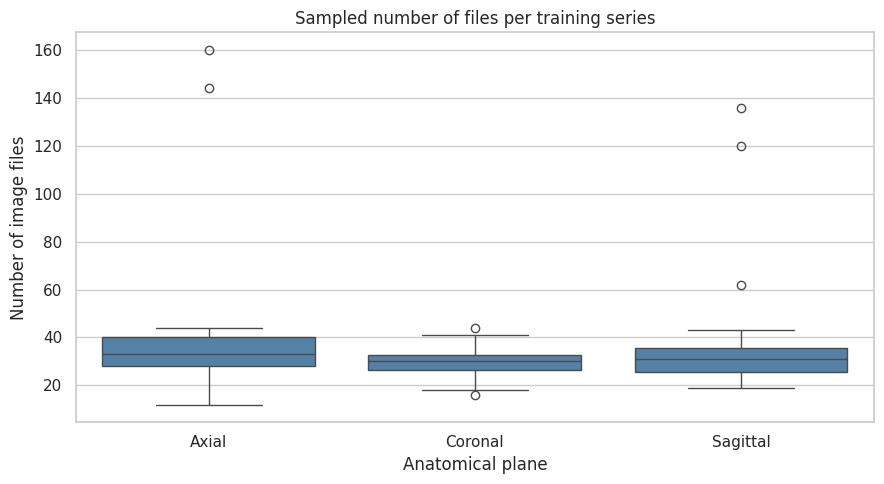

In [41]:
# 41. Sample the number of image files per series

sampled_train_series = pd.concat([
    group.sample(
        n=min(50, len(group)),
        random_state=RANDOM_STATE,
    )
    for _, group in train_series.groupby("Anatomical_Plane")
])

sampled_series_tables = [
    ("Train", sampled_train_series, TRAIN_IMAGES_ROOT),
    ("Test", test_series, TEST_IMAGES_ROOT),
]

sampled_file_rows = []

for split_name, series_table, image_root in sampled_series_tables:
    for row in series_table[
        [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane"]
    ].itertuples(index=False):
        study_uid = getattr(row, ID_COLUMN)
        series_uid = row.SeriesInstanceUID
        series_path = image_root / study_uid / series_uid

        if not series_path.exists():
            sampled_file_rows.append({
                "split": split_name,
                "anatomical_plane": row.Anatomical_Plane,
                "number_of_files": np.nan,
                "directory_exists": False,
            })
            continue

        number_of_files = sum(
            entry.is_file(follow_symlinks=False)
            for entry in os.scandir(series_path)
        )

        sampled_file_rows.append({
            "split": split_name,
            "anatomical_plane": row.Anatomical_Plane,
            "number_of_files": number_of_files,
            "directory_exists": True,
        })

sampled_file_inventory = pd.DataFrame(sampled_file_rows)

sampled_file_summary = (
    sampled_file_inventory
    .groupby("split")
    .agg(
        sampled_series=("number_of_files", "size"),
        missing_directories=(
            "directory_exists",
            lambda values: (~values).sum(),
        ),
        minimum_files=("number_of_files", "min"),
        median_files=("number_of_files", "median"),
        mean_files=("number_of_files", "mean"),
        maximum_files=("number_of_files", "max"),
    )
    .reset_index()
)

display(sampled_file_summary)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=sampled_file_inventory.loc[
        sampled_file_inventory["split"] == "Train"
    ],
    x="anatomical_plane",
    y="number_of_files",
    color="steelblue",
)

plt.title("Sampled number of files per training series")
plt.xlabel("Anatomical plane")
plt.ylabel("Number of image files")
plt.tight_layout()
plt.show()


### Observation — slice counts vary across series

The sampled series contain a median of 30 image files. The training sample ranges from 12 to 160 files, while the visible test series range from 24 to 160.

Coronal series have the tightest distribution in this sample. Axial and sagittal series show more variation and several high-count outliers. These counts describe files in a series, but they do not yet tell us whether image dimensions, spacing or other DICOM properties also vary.

The test summary is based on only 15 series, so it should not be treated as representative of the full hidden test set.

## DICOM header metadata

DICOM files contain more information than the CSV metadata, including image dimensions, pixel spacing, slice thickness and acquisition identifiers.

We inspect one representative image from a small sample of series to check these properties and confirm that the identifiers stored inside the DICOM files agree with the directory structure.

In [42]:
# 42. Inspect representative DICOM headers

import pydicom

header_train_series = pd.concat([
    group.sample(
        n=min(3, len(group)),
        random_state=RANDOM_STATE,
    )
    for _, group in train_series.groupby("Anatomical_Plane")
])

header_sample_tables = [
    ("Train", header_train_series, TRAIN_IMAGES_ROOT),
    ("Test", test_series, TEST_IMAGES_ROOT),
]

dicom_header_rows = []

for split_name, series_table, image_root in header_sample_tables:
    for row in series_table[
        [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane"]
    ].itertuples(index=False):

        study_uid = getattr(row, ID_COLUMN)
        series_uid = row.SeriesInstanceUID
        series_path = image_root / study_uid / series_uid

        if not series_path.exists():
            continue

        dicom_entries = sorted(
            [
                entry
                for entry in os.scandir(series_path)
                if (
                    entry.is_file(follow_symlinks=False)
                    and Path(entry.name).suffix.lower() == ".dcm"
                )
            ],
            key=lambda entry: entry.name,
        )

        if not dicom_entries:
            continue

        dicom_path = Path(dicom_entries[0].path)

        dataset = pydicom.dcmread(
            dicom_path,
            stop_before_pixels=True,
        )

        dicom_header_rows.append({
            "split": split_name,
            ID_COLUMN: study_uid,
            "SeriesInstanceUID": series_uid,
            "file_name": dicom_path.name,
            "anatomical_plane": row.Anatomical_Plane,
            "Modality": dataset.get("Modality"),
            "Rows": dataset.get("Rows"),
            "Columns": dataset.get("Columns"),
            "PixelSpacing": str(dataset.get("PixelSpacing")),
            "SliceThickness": dataset.get("SliceThickness"),
            "SpacingBetweenSlices": dataset.get(
                "SpacingBetweenSlices"
            ),
            "InstanceNumber": dataset.get("InstanceNumber"),
            "PhotometricInterpretation": dataset.get(
                "PhotometricInterpretation"
            ),
            "BitsAllocated": dataset.get("BitsAllocated"),
            "study_uid_matches_directory": (
                dataset.get("StudyInstanceUID") == study_uid
            ),
            "series_uid_matches_directory": (
                dataset.get("SeriesInstanceUID") == series_uid
            ),
        })

dicom_header_sample = pd.DataFrame(dicom_header_rows)

print(f"pydicom version: {pydicom.__version__}")

display(dicom_header_sample)


pydicom version: 3.0.2


,split,StudyInstanceUID,SeriesInstanceUID,file_name,anatomical_plane,Modality,Rows,Columns,PixelSpacing,SliceThickness,SpacingBetweenSlices,InstanceNumber,PhotometricInterpretation,BitsAllocated,study_uid_matches_directory,series_uid_matches_directory
0,Train,1.2.826.0.1.3680043.8.498.97269744864161337523...,1.2.826.0.1.3680043.8.498.43704838744387350842...,1.2.826.0.1.3680043.8.498.10034350416717081987...,Axial,MR,448,448,"[0.35714286565780, 0.35714286565780]",4.0000,4.4000,4,MONOCHROME2,16,True,True
1,Train,1.2.826.0.1.3680043.8.498.21135201439483157418...,1.2.826.0.1.3680043.8.498.10088722197008341424...,1.2.826.0.1.3680043.8.498.10261098959915684000...,Axial,MR,960,960,"[0.1562, 0.1562]",3.0000,3.3000,21,MONOCHROME2,16,True,True
2,Train,1.2.826.0.1.3680043.8.498.16589468854653713035...,1.2.826.0.1.3680043.8.498.10967513081022648012...,1.2.826.0.1.3680043.8.498.10476079139759061842...,Axial,MR,512,512,"[0.3125, 0.3125]",5.0000,5.5000,25,MONOCHROME2,16,True,True
3,Train,1.2.826.0.1.3680043.8.498.99957611207313098696...,1.2.826.0.1.3680043.8.498.62870298129639401344...,1.2.826.0.1.3680043.8.498.10901007858590425931...,Coronal,MR,560,560,"[0.32142856717109, 0.32142856717109]",4.0000,5.0300,15,MONOCHROME2,16,True,True
4,Train,1.2.826.0.1.3680043.8.498.12509944331769453135...,1.2.826.0.1.3680043.8.498.12411158088598982086...,1.2.826.0.1.3680043.8.498.10271878241105524106...,Coronal,MR,704,704,"[0.22727273404598, 0.22727273404598]",3.0000,3.3000,23,MONOCHROME2,16,True,True
5,Train,1.2.826.0.1.3680043.8.498.60163612617486071760...,1.2.826.0.1.3680043.8.498.84864405435435772039...,1.2.826.0.1.3680043.8.498.10034430628337593299...,Coronal,MR,320,320,"[0.5, 0.5]",3.0000,3.3000,10,MONOCHROME2,16,True,True
6,Train,1.2.826.0.1.3680043.8.498.98454206323401382140...,1.2.826.0.1.3680043.8.498.46948743524877746104...,1.2.826.0.1.3680043.8.498.10019407161276661661...,Sagittal,MR,512,512,"[0.2734, 0.2734]",2.7900,1.4000,37,MONOCHROME2,16,True,True
7,Train,1.2.826.0.1.3680043.8.498.10600654987896381983...,1.2.826.0.1.3680043.8.498.13312095336842228726...,1.2.826.0.1.3680043.8.498.10013674092258170047...,Sagittal,MR,512,512,"[0.3906, 0.3906]",2.0000,1.0000,114,MONOCHROME2,16,True,True
8,Train,1.2.826.0.1.3680043.8.498.38974023308452365783...,1.2.826.0.1.3680043.8.498.52051618150267320257...,1.2.826.0.1.3680043.8.498.10367954001848054867...,Sagittal,MR,384,384,"[0.416667, 0.416667]",3.0000,3.3000,13,MONOCHROME2,16,True,True
9,Test,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,1.2.826.0.1.3680043.8.498.10492923471392639089...,Axial,MR,960,960,"[0.1562, 0.1562]",3.0000,3.3000,26,MONOCHROME2,16,True,True


### Observation — DICOM identifiers are consistent, but image geometry varies

All sampled files are genuine MR DICOM images with `MONOCHROME2` photometric interpretation and 16-bit pixel storage. The `StudyInstanceUID` and `SeriesInstanceUID` values inside the files agree with the directory structure, which provides an additional integrity check.

The image geometry is not uniform. In the sample, image dimensions range from 320×320 to 960×960, with one test series measuring 640×1,280. Pixel spacing ranges from approximately 0.156 to 0.500 mm, while slice thickness ranges from 0.6 to 5.0 mm.

This variation will matter for preprocessing. A model may need consistent resizing and possibly spatial resampling, and slices should be ordered using DICOM metadata rather than filenames. The missing `SpacingBetweenSlices` values in some test files are not automatically an error because this tag is optional; image positions may provide a better way to determine slice spacing.

## Visual MRI sanity check

We now display one representative series from each anatomical plane for a single training study. The slices are ordered using their DICOM `InstanceNumber` values rather than relying on file-name order.

The contrast adjustment is used only to make the images easier to view. It is not a final preprocessing method.

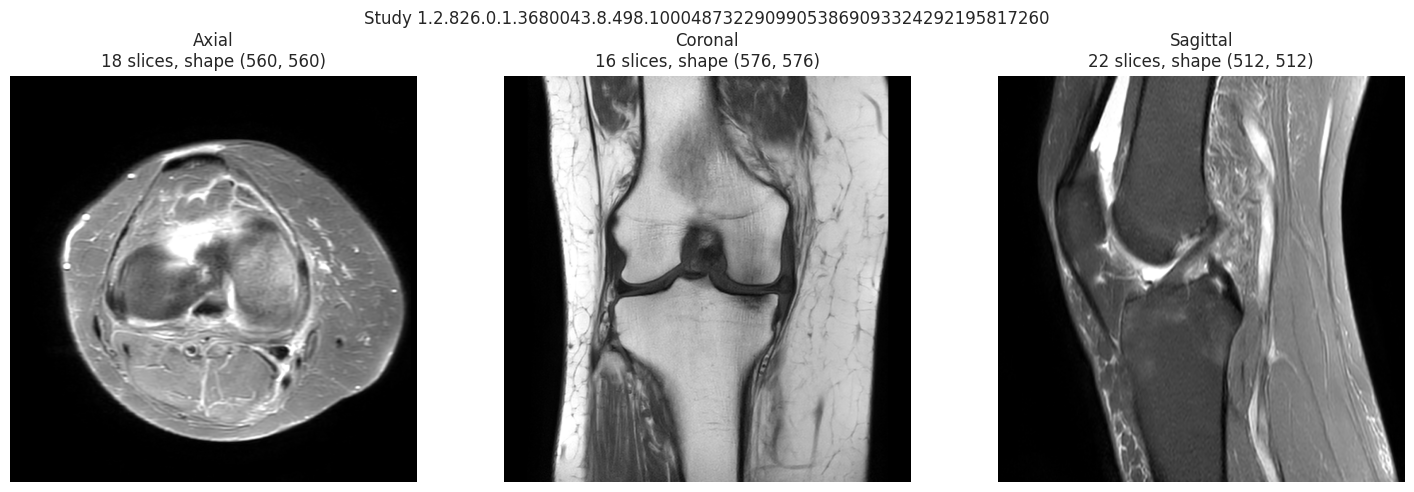

In [43]:
# 43. Display one ordered middle slice per anatomical plane

def get_ordered_dicom_paths(study_uid, series_uid, image_root):
    series_path = image_root / study_uid / series_uid

    dicom_paths = sorted(
        [
            Path(entry.path)
            for entry in os.scandir(series_path)
            if (
                entry.is_file(follow_symlinks=False)
                and Path(entry.name).suffix.lower() == ".dcm"
            )
        ],
        key=lambda path: path.name,
    )

    ordered_paths = []

    for path in dicom_paths:
        header = pydicom.dcmread(
            path,
            stop_before_pixels=True,
            specific_tags=["InstanceNumber"],
        )

        instance_number = header.get("InstanceNumber")

        try:
            instance_number = float(instance_number)
        except (TypeError, ValueError):
            instance_number = np.nan

        ordered_paths.append({
            "path": path,
            "instance_number": instance_number,
        })

    return sorted(
        ordered_paths,
        key=lambda item: (
            pd.isna(item["instance_number"]),
            item["instance_number"]
            if not pd.isna(item["instance_number"])
            else 0,
            item["path"].name,
        ),
    )


def load_display_image(path):
    dataset = pydicom.dcmread(path)
    image = dataset.pixel_array.astype(np.float32)

    slope = float(dataset.get("RescaleSlope", 1.0))
    intercept = float(dataset.get("RescaleIntercept", 0.0))

    image = image * slope + intercept

    lower, upper = np.percentile(image, [1, 99])

    if upper > lower:
        image = np.clip(image, lower, upper)
        image = (image - lower) / (upper - lower)

    return image, dataset


sample_study_uid = train_series[ID_COLUMN].iloc[0]
study_series = train_series.loc[
    train_series[ID_COLUMN] == sample_study_uid
]

plane_order = ["Axial", "Coronal", "Sagittal"]

fig, axes = plt.subplots(
    1,
    len(plane_order),
    figsize=(15, 5),
)

for ax, plane in zip(axes, plane_order):
    plane_rows = study_series.loc[
        study_series["Anatomical_Plane"] == plane
    ]

    if plane_rows.empty:
        ax.set_title(f"{plane}\nnot available")
        ax.axis("off")
        continue

    series_uid = plane_rows["SeriesInstanceUID"].iloc[0]

    ordered_files = get_ordered_dicom_paths(
        sample_study_uid,
        series_uid,
        TRAIN_IMAGES_ROOT,
    )

    middle_index = len(ordered_files) // 2
    middle_file = ordered_files[middle_index]

    image, dataset = load_display_image(
        middle_file["path"]
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"{plane}\n"
        f"{len(ordered_files)} slices, "
        f"shape {image.shape}"
    )
    ax.axis("off")

fig.suptitle(
    f"Study {sample_study_uid}",
    fontsize=12,
)

plt.tight_layout()
plt.show()


### Observation — the image data contain plausible multi-plane knee MRI

The three displayed series have the expected anatomical orientations and clearly show knee anatomy. The number of slices and image dimensions differ between planes, confirming that the series are not identical copies of one another.

This is a visual sanity check rather than a diagnostic interpretation. Image contrast also varies between sequences, so the display window used here is only for visualisation and should not yet be treated as the final model preprocessing method.

## Geometry variation across series

MRI series may differ in image dimensions, pixel spacing and slice thickness. These differences determine whether images can be resized directly or whether spatial resampling will be needed before modelling.

We inspect a sample of series rather than reading every DICOM file.

Successfully inspected 200 of 200 sampled series.
Series with header-reading errors: 0


rows             columns            pixel_spacing_row_mm  \
                   median  min   max   median  min   max               median   
anatomical_plane                                                                
Axial            512.0000  256   960 512.0000  256  1280               0.3125   
Coronal          512.0000  256  1024 512.0000  256  1024               0.3075   
Sagittal         480.0000  256  1024 464.0000  256  1024               0.3571   

                               pixel_spacing_col_mm                \
                    min    max               median    min    max   
anatomical_plane                                                    
Axial            0.1562 0.6250               0.3125 0.1562 0.6250   
Coronal          0.1367 0.7031               0.3075 0.1367 0.7031   
Sagittal         0.1367 0.7813               0.3571 0.1367 0.7813   

                 slice_thickness_mm               num_slices_in_series      \
                             median    min    max               median min   
anatomical_plane                                                             
Axial                        3.0000 0.6000 5.0000              32.0000  12   
Coronal                      3.0000 2.0000 4.5000              30.0000  16   
Sagittal                     3.0000 0.6500 4.0000              30.0000  11   

                       
                  max  
anatomical_plane       
Axial             144  
Coronal            45  
Sagittal          320

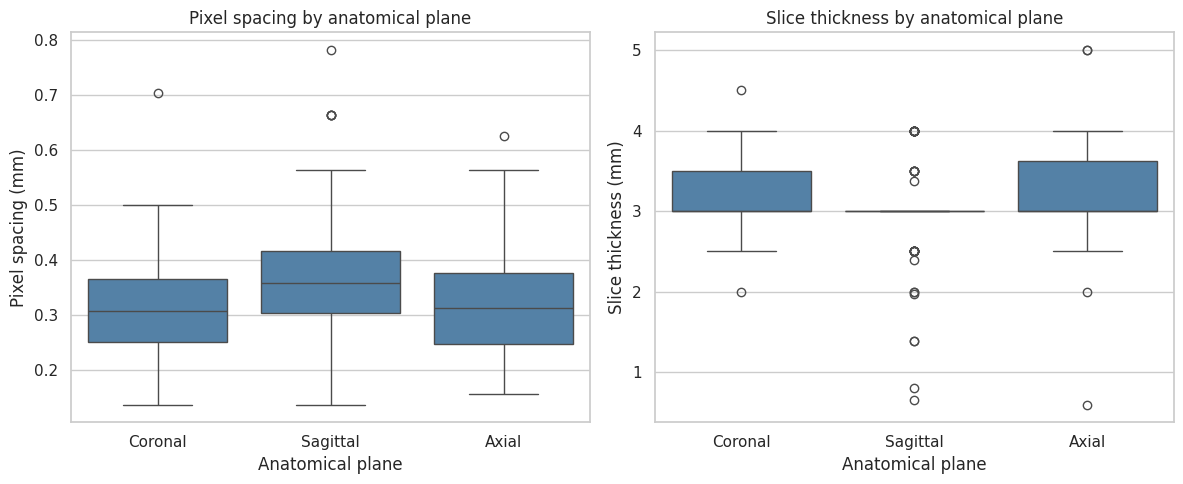

In [44]:
# 44. Audit DICOM geometry across a sample of series

GEOMETRY_SAMPLE_SIZE = 200

geometry_series_sample = train_series.sample(
    n=min(GEOMETRY_SAMPLE_SIZE, len(train_series)),
    random_state=RANDOM_STATE,
)

geometry_rows = []

for row in geometry_series_sample[
    [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane"]
].itertuples(index=False):

    study_uid = getattr(row, ID_COLUMN)
    series_uid = row.SeriesInstanceUID
    series_path = TRAIN_IMAGES_ROOT / study_uid / series_uid

    dicom_paths = sorted(
        [
            Path(entry.path)
            for entry in os.scandir(series_path)
            if (
                entry.is_file(follow_symlinks=False)
                and Path(entry.name).suffix.lower() == ".dcm"
            )
        ],
        key=lambda path: path.name,
    )

    if not dicom_paths:
        geometry_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "error": "No DICOM files found",
        })
        continue

    try:
        dataset = pydicom.dcmread(
            dicom_paths[0],
            stop_before_pixels=True,
        )

        pixel_spacing = dataset.get(
            "PixelSpacing",
            [np.nan, np.nan],
        )

        try:
            pixel_spacing_row = float(pixel_spacing[0])
            pixel_spacing_col = float(pixel_spacing[1])
        except (TypeError, ValueError, IndexError):
            pixel_spacing_row = np.nan
            pixel_spacing_col = np.nan

        geometry_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "rows": dataset.get("Rows", np.nan),
            "columns": dataset.get("Columns", np.nan),
            "pixel_spacing_row_mm": pixel_spacing_row,
            "pixel_spacing_col_mm": pixel_spacing_col,
            "slice_thickness_mm": dataset.get(
                "SliceThickness",
                np.nan,
            ),
            "spacing_between_slices_mm": dataset.get(
                "SpacingBetweenSlices",
                np.nan,
            ),
            "bits_stored": dataset.get(
                "BitsStored",
                np.nan,
            ),
            "num_slices_in_series": len(dicom_paths),
        })

    except Exception as error:
        geometry_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "error": str(error),
        })

geometry_audit = pd.DataFrame(geometry_rows)

if "error" in geometry_audit.columns:
    error_mask = geometry_audit["error"].notna()
else:
    error_mask = pd.Series(
        False,
        index=geometry_audit.index,
    )

valid_geometry = geometry_audit.loc[
    ~error_mask
].copy()

number_of_errors = int(error_mask.sum())

numeric_geometry_columns = [
    "rows",
    "columns",
    "pixel_spacing_row_mm",
    "pixel_spacing_col_mm",
    "slice_thickness_mm",
    "spacing_between_slices_mm",
    "bits_stored",
    "num_slices_in_series",
]

for column in numeric_geometry_columns:
    if column in valid_geometry.columns:
        valid_geometry[column] = pd.to_numeric(
            valid_geometry[column],
            errors="coerce",
        )

print(
    f"Successfully inspected "
    f"{len(valid_geometry)} "
    f"of {len(geometry_audit)} sampled series."
)
print(f"Series with header-reading errors: {number_of_errors}")

geometry_summary = (
    valid_geometry
    .groupby("anatomical_plane")[
        [
            "rows",
            "columns",
            "pixel_spacing_row_mm",
            "pixel_spacing_col_mm",
            "slice_thickness_mm",
            "num_slices_in_series",
        ]
    ]
    .agg(["median", "min", "max"])
)

display(geometry_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=valid_geometry,
    x="anatomical_plane",
    y="pixel_spacing_row_mm",
    color="steelblue",
    ax=axes[0],
)

axes[0].set_title("Pixel spacing by anatomical plane")
axes[0].set_xlabel("Anatomical plane")
axes[0].set_ylabel("Pixel spacing (mm)")

sns.boxplot(
    data=valid_geometry,
    x="anatomical_plane",
    y="slice_thickness_mm",
    color="steelblue",
    ax=axes[1],
)

axes[1].set_title("Slice thickness by anatomical plane")
axes[1].set_xlabel("Anatomical plane")
axes[1].set_ylabel("Slice thickness (mm)")

plt.tight_layout()
plt.show()


### Observation — MRI geometry varies substantially

All 200 sampled series were read successfully, with no DICOM header errors.

The image geometry varies considerably:

- image dimensions range from 256 pixels to as many as 1,280 pixels in an axis;
- median images are approximately 512×512 pixels;
- pixel spacing ranges from about 0.137 mm to 0.781 mm;
- median slice thickness is approximately 3 mm, but ranges from roughly 0.6 mm to 5 mm;
- sagittal series show a particularly long slice-count tail, reaching 320 slices in the sample.

This means that resizing every image to the same pixel dimensions will not necessarily make the physical anatomy comparable. Any future preprocessing should consider pixel spacing and slice geometry, rather than treating the raw pixel grid as physically uniform.

These results come from a sample of 200 series, so the exact minimum and maximum values should not be treated as full-dataset limits.

## Gold-labelled visual example

We now display one English-language gold-labelled study with its positive targets, report excerpt and representative MRI views.

This is a qualitative illustration only. The labels apply to the entire study, and a single middle slice from each series will not necessarily show every abnormality.

Study: 1.2.826.0.1.3680043.8.498.64703506772167798469048460791472465039
Language: English
Positive targets: MCL, Medial Meniscus, Lateral Meniscus, Effusion, Contusion, Fracture

Report excerpt:
FINDINGS: Fractures: Known mildly comminuted undisplaced avulsion fracture of the tibial tuberosity involving the distal ACL insertion, anteriorly the anterior horn root insertion of the lateral meniscus, as well as posteriorly the tibial insertion of both the posterior horn of medial and lateral ... he anterior cruciate ligament and lateral collateral ligament. *Additional low-grade tears involving the medial and lateral menisci as described. *Moderate grade partial tear of the medial patellar retinaculum. *Posteromedial and posterolateral corner injuries as described. *Large joint effusion.


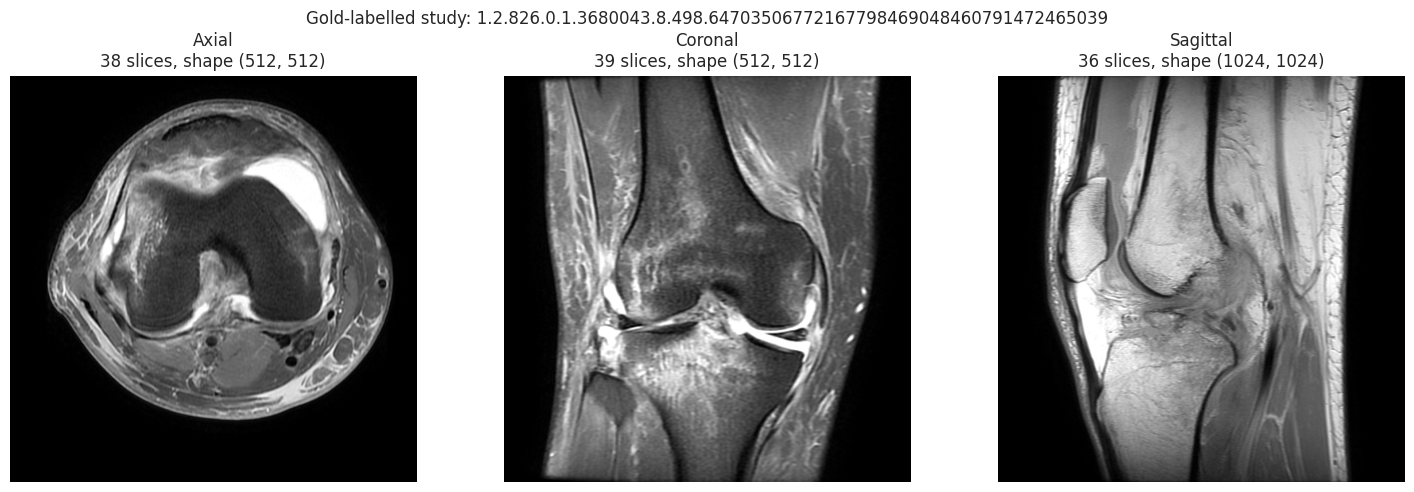

In [45]:
# 45. Display a gold-labelled study with targets and MRI views

TARGET_TO_ILLUSTRATE = "Effusion"

gold_english_candidates = gold_report_data.loc[
    (gold_report_data["language"] == "English")
    & (gold_report_data[TARGET_TO_ILLUSTRATE] == 1),
    ID_COLUMN,
]

example_study_uid = gold_english_candidates.sample(
    n=1,
    random_state=RANDOM_STATE,
).iloc[0]

example_row = gold_report_data.loc[
    gold_report_data[ID_COLUMN] == example_study_uid
].iloc[0]

print(f"Study: {example_study_uid}")
print(f"Language: {example_row['language']}")
print(f"Positive targets: {example_row['positive_targets']}")
print()
print("Report excerpt:")
print(create_report_excerpt(example_row["Report"], 600))

study_series = train_series.loc[
    train_series[ID_COLUMN] == example_study_uid
]

fig, axes = plt.subplots(
    1,
    len(plane_order),
    figsize=(15, 5),
)

for ax, plane in zip(axes, plane_order):
    plane_rows = study_series.loc[
        study_series["Anatomical_Plane"] == plane
    ]

    if plane_rows.empty:
        ax.set_title(f"{plane}\nnot available")
        ax.axis("off")
        continue

    series_uid = plane_rows["SeriesInstanceUID"].iloc[0]

    ordered_files = get_ordered_dicom_paths(
        example_study_uid,
        series_uid,
        TRAIN_IMAGES_ROOT,
    )

    middle_index = len(ordered_files) // 2
    middle_file = ordered_files[middle_index]

    image, dataset = load_display_image(
        middle_file["path"]
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"{plane}\n"
        f"{len(ordered_files)} slices, "
        f"shape {image.shape}"
    )
    ax.axis("off")

fig.suptitle(
    f"Gold-labelled study: {example_study_uid}",
    fontsize=12,
)

plt.tight_layout()
plt.show()


### Observation — a single study can contain many co-existing abnormalities

This gold-labelled study has six positive targets. The report explicitly describes a fracture, meniscal injuries and a large joint effusion, alongside additional ligament and soft-tissue findings.

The three MRI views show a plausible knee examination with different anatomical perspectives and acquisition resolutions. However, these are representative middle slices, so they cannot independently confirm every study-level label. The example mainly demonstrates that the task is multi-label and study-level: abnormalities may be distributed across different slices and planes.

## Spatial order and image-identifier integrity

A valid MRI stack needs more than unique identifiers. In a sample of series, we inspect `InstanceNumber`, `SOPInstanceUID`, `ImagePositionPatient` and `ImageOrientationPatient`, and test whether instance-number order is spatially monotonic.

Under the DICOM Image Plane Module, image position and orientation jointly describe a slice in the patient coordinate system. `SpacingBetweenSlices` is optional, so spatial coordinates are preferable when they are available.


In [46]:
# 46. Audit spatial ordering and identifiers in sampled series

SLICE_AUDIT_SAMPLE_SIZE = 50
POSITION_TOLERANCE_MM = 1e-3
ORIENTATION_TOLERANCE = 1e-4

slice_audit_sample = train_series.sample(
    n=min(SLICE_AUDIT_SAMPLE_SIZE, len(train_series)),
    random_state=RANDOM_STATE,
)

slice_audit_rows = []

for row in slice_audit_sample[
    [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane"]
].itertuples(index=False):
    study_uid = getattr(row, ID_COLUMN)
    series_uid = row.SeriesInstanceUID
    series_path = TRAIN_IMAGES_ROOT / study_uid / series_uid

    dicom_paths = sorted(
        [
            Path(entry.path)
            for entry in os.scandir(series_path)
            if entry.is_file(follow_symlinks=False)
            and Path(entry.name).suffix.lower() == ".dcm"
        ],
        key=lambda path: path.name,
    )

    records = []
    for dicom_path in dicom_paths:
        dataset = pydicom.dcmread(
            dicom_path,
            stop_before_pixels=True,
            specific_tags=[
                "InstanceNumber",
                "SOPInstanceUID",
                "ImagePositionPatient",
                "ImageOrientationPatient",
                "Rows",
                "Columns",
                "PixelSpacing",
            ],
        )

        def numeric_vector(value, expected_length):
            try:
                vector = np.asarray(value, dtype=float)
                return vector if vector.size == expected_length else None
            except (TypeError, ValueError):
                return None

        try:
            instance_number = float(dataset.get("InstanceNumber"))
        except (TypeError, ValueError):
            instance_number = np.nan

        records.append({
            "instance_number": instance_number,
            "sop_uid": str(dataset.get("SOPInstanceUID", "")).strip(),
            "position": numeric_vector(
                dataset.get("ImagePositionPatient"), 3
            ),
            "orientation": numeric_vector(
                dataset.get("ImageOrientationPatient"), 6
            ),
            "shape": (
                dataset.get("Rows"),
                dataset.get("Columns"),
            ),
            "pixel_spacing": numeric_vector(
                dataset.get("PixelSpacing"), 2
            ),
        })

    valid_positions = [record["position"] for record in records if record["position"] is not None]
    valid_orientations = [record["orientation"] for record in records if record["orientation"] is not None]
    instance_numbers = [record["instance_number"] for record in records]
    sop_uids = [record["sop_uid"] for record in records]

    orientation_consistent = np.nan
    spatial_order_monotonic = np.nan
    duplicate_positions = np.nan
    irregular_spatial_spacing = np.nan

    if len(valid_orientations) == len(records) and records:
        reference_orientation = valid_orientations[0]
        orientation_consistent = all(
            np.allclose(
                orientation,
                reference_orientation,
                atol=ORIENTATION_TOLERANCE,
                rtol=0,
            )
            for orientation in valid_orientations
        )

        if len(valid_positions) == len(records) and orientation_consistent:
            row_direction = reference_orientation[:3]
            column_direction = reference_orientation[3:]
            slice_normal = np.cross(row_direction, column_direction)
            slice_normal /= np.linalg.norm(slice_normal)

            projections = np.asarray([
                float(np.dot(record["position"], slice_normal))
                for record in records
            ])
            rounded_positions = np.round(
                projections / POSITION_TOLERANCE_MM
            ).astype(int)
            duplicate_positions = (
                len(rounded_positions) != len(set(rounded_positions))
            )

            position_steps = np.diff(np.sort(projections))
            if len(position_steps) > 1:
                median_step = np.median(position_steps)
                irregular_spatial_spacing = bool(
                    np.max(np.abs(position_steps - median_step))
                    > max(0.1, 0.05 * abs(median_step))
                )
            else:
                irregular_spatial_spacing = False

            if not any(pd.isna(instance_numbers)):
                instance_order = np.argsort(instance_numbers)
                ordered_steps = np.diff(projections[instance_order])
                spatial_order_monotonic = bool(
                    np.all(ordered_steps > POSITION_TOLERANCE_MM)
                    or np.all(ordered_steps < -POSITION_TOLERANCE_MM)
                )

    shapes = [record["shape"] for record in records]
    spacings = [
        tuple(np.round(record["pixel_spacing"], 6))
        for record in records
        if record["pixel_spacing"] is not None
    ]

    slice_audit_rows.append({
        "StudyInstanceUID": study_uid,
        "SeriesInstanceUID": series_uid,
        "anatomical_plane": row.Anatomical_Plane,
        "number_of_files": len(records),
        "empty_series": len(records) == 0,
        "missing_instance_numbers": any(pd.isna(instance_numbers)),
        "duplicate_instance_numbers": (
            len(instance_numbers) != len(set(instance_numbers))
            if not any(pd.isna(instance_numbers)) else np.nan
        ),
        "missing_sop_instance_uids": any(not value for value in sop_uids),
        "duplicate_sop_instance_uids": (
            len(sop_uids) != len(set(sop_uids))
            if all(sop_uids) else np.nan
        ),
        "missing_image_positions": len(valid_positions) < len(records),
        "missing_image_orientations": len(valid_orientations) < len(records),
        "orientation_consistent": orientation_consistent,
        "duplicate_image_positions": duplicate_positions,
        "instance_order_spatially_monotonic": spatial_order_monotonic,
        "irregular_spatial_spacing": irregular_spatial_spacing,
        "inconsistent_slice_dimensions": len(set(shapes)) > 1,
        "inconsistent_pixel_spacing": (
            len(spacings) != len(records) or len(set(spacings)) > 1
        ),
    })

slice_audit = pd.DataFrame(slice_audit_rows)

audit_columns = [
    "empty_series",
    "missing_instance_numbers",
    "duplicate_instance_numbers",
    "missing_sop_instance_uids",
    "duplicate_sop_instance_uids",
    "missing_image_positions",
    "missing_image_orientations",
    "inconsistent_slice_dimensions",
    "inconsistent_pixel_spacing",
    "duplicate_image_positions",
    "irregular_spatial_spacing",
]

slice_audit_summary = pd.DataFrame({
    "check": [column.replace("_", " ").title() for column in audit_columns],
    "series_affected": [
        int(slice_audit[column].fillna(False).sum())
        for column in audit_columns
    ],
})

spatial_order_summary = (
    slice_audit["instance_order_spatially_monotonic"]
    .map({True: "Monotonic", False: "Not monotonic"})
    .fillna("Not assessable")
    .value_counts()
    .rename_axis("instance/spatial order")
    .reset_index(name="series")
)

display(slice_audit_summary)
display(spatial_order_summary)


,check,series_affected
0,Empty Series,0
1,Missing Instance Numbers,0
2,Duplicate Instance Numbers,0
3,Missing Sop Instance Uids,0
4,Duplicate Sop Instance Uids,0
5,Missing Image Positions,0
6,Missing Image Orientations,0
7,Inconsistent Slice Dimensions,0
8,Inconsistent Pixel Spacing,0
9,Duplicate Image Positions,0


,instance/spatial order,series
0,Monotonic,50


### Observation — sampled MRI stacks have consistent spatial ordering

All 50 sampled series passed the identifier and spatial-integrity checks. No missing or duplicated instance numbers, SOP identifiers, image positions or image orientations were found.

Image dimensions, pixel spacing and orientation were consistent within every sampled stack. No duplicate positions or irregular spatial spacing were detected, and `InstanceNumber` order was spatially monotonic in all 50 series.

These results support using DICOM metadata to assemble the sampled volumes. Spatial position remains the most defensible ordering field, with `InstanceNumber` providing a consistent fallback in this sample.


## Pixel data integrity

In [47]:
# 47. Check representative pixel decoding

PIXEL_AUDIT_SAMPLE_SIZE = 100

pixel_audit_sample = train_series.sample(
    n=min(PIXEL_AUDIT_SAMPLE_SIZE, len(train_series)),
    random_state=RANDOM_STATE + 1,
)

pixel_audit_rows = []

for row in pixel_audit_sample[
    [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane"]
].itertuples(index=False):

    study_uid = getattr(row, ID_COLUMN)
    series_uid = row.SeriesInstanceUID
    series_path = TRAIN_IMAGES_ROOT / study_uid / series_uid

    try:
        dicom_paths = sorted(
            [
                Path(entry.path)
                for entry in os.scandir(series_path)
                if (
                    entry.is_file(follow_symlinks=False)
                    and Path(entry.name).suffix.lower() == ".dcm"
                )
            ],
            key=lambda path: path.name,
        )

        if not dicom_paths:
            raise FileNotFoundError("No DICOM files found")

        representative_path = dicom_paths[len(dicom_paths) // 2]

        dataset = pydicom.dcmread(representative_path)
        pixel_array = dataset.pixel_array

        expected_shape = (
            int(dataset.Rows),
            int(dataset.Columns),
        )
        actual_shape = tuple(pixel_array.shape[-2:])

        pixel_audit_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "expected_shape": expected_shape,
            "actual_shape": actual_shape,
            "shape_matches": expected_shape == actual_shape,
            "has_non_finite_values": not np.isfinite(pixel_array).all(),
            "is_constant_image": np.ptp(pixel_array) == 0,
            "error": None,
        })

    except Exception as error:
        pixel_audit_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "expected_shape": None,
            "actual_shape": None,
            "shape_matches": False,
            "has_non_finite_values": False,
            "is_constant_image": False,
            "error": f"{type(error).__name__}: {error}",
        })

pixel_audit = pd.DataFrame(pixel_audit_rows)

pixel_audit_summary = pd.DataFrame({
    "check": [
        "Sampled series",
        "Representative pixel arrays decoded",
        "Header/image shape mismatches",
        "Images with non-finite values",
        "Constant representative images",
        "Series with decoding errors",
    ],
    "series_affected": [
        len(pixel_audit),
        pixel_audit["error"].isna().sum(),
        ((pixel_audit["error"].isna()) & (~pixel_audit["shape_matches"])).sum(),
        pixel_audit["has_non_finite_values"].sum(),
        pixel_audit["is_constant_image"].sum(),
        pixel_audit["error"].notna().sum(),
    ],
})

display(pixel_audit_summary)

if pixel_audit["error"].notna().any():
    display(
        pixel_audit.loc[
            pixel_audit["error"].notna(),
            [
                "StudyInstanceUID",
                "SeriesInstanceUID",
                "anatomical_plane",
                "error",
            ],
        ]
    )


,check,series_affected
0,Sampled series,100
1,Representative pixel arrays decoded,100
2,Header/image shape mismatches,0
3,Images with non-finite values,0
4,Constant representative images,0
5,Series with decoding errors,0


### Observation — sampled pixel data are readable

All 100 sampled series successfully decoded representative pixel arrays. The decoded image shapes matched the recorded DICOM dimensions, with no non-finite or constant images detected.

This indicates that the dataset has no immediate pixel-decoding or image-shape problems in the sample. Pixel intensities may still vary between scanners and sequences, so normalization should be examined before modelling.

## Pixel intensity variation

In [48]:
# 48. Audit representative pixel intensity ranges

intensity_audit_rows = []

for row in pixel_audit_sample[
    [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane"]
].itertuples(index=False):

    study_uid = getattr(row, ID_COLUMN)
    series_uid = row.SeriesInstanceUID
    series_path = TRAIN_IMAGES_ROOT / study_uid / series_uid

    try:
        dicom_paths = sorted(
            [
                Path(entry.path)
                for entry in os.scandir(series_path)
                if (
                    entry.is_file(follow_symlinks=False)
                    and Path(entry.name).suffix.lower() == ".dcm"
                )
            ],
            key=lambda path: path.name,
        )

        representative_path = dicom_paths[len(dicom_paths) // 2]
        dataset = pydicom.dcmread(representative_path)

        pixel_array = dataset.pixel_array.astype(np.float32)

        rescale_slope = float(dataset.get("RescaleSlope", 1.0))
        rescale_intercept = float(dataset.get("RescaleIntercept", 0.0))

        intensity_array = (
            pixel_array * rescale_slope
            + rescale_intercept
        )

        p01, median, p99 = np.percentile(
            intensity_array,
            [1, 50, 99],
        )

        intensity_audit_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "p01": p01,
            "median": median,
            "p99": p99,
            "display_range": p99 - p01,
            "rescale_slope": rescale_slope,
            "rescale_intercept": rescale_intercept,
            "error": None,
        })

    except Exception as error:
        intensity_audit_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "p01": np.nan,
            "median": np.nan,
            "p99": np.nan,
            "display_range": np.nan,
            "rescale_slope": np.nan,
            "rescale_intercept": np.nan,
            "error": f"{type(error).__name__}: {error}",
        })

intensity_audit = pd.DataFrame(intensity_audit_rows)

valid_intensity_audit = intensity_audit[
    intensity_audit["error"].isna()
].copy()

intensity_summary = (
    valid_intensity_audit
    .groupby("anatomical_plane")
    .agg(
        series_sampled=("SeriesInstanceUID", "count"),
        median_p01=("p01", "median"),
        median_pixel_value=("median", "median"),
        median_p99=("p99", "median"),
        median_display_range=("display_range", "median"),
        minimum_display_range=("display_range", "min"),
        maximum_display_range=("display_range", "max"),
    )
    .round(3)
    .reset_index()
)

display(intensity_summary)

if intensity_audit["error"].notna().any():
    display(
        intensity_audit.loc[
            intensity_audit["error"].notna(),
            [
                "StudyInstanceUID",
                "SeriesInstanceUID",
                "anatomical_plane",
                "error",
            ],
        ]
    )


,anatomical_plane,series_sampled,median_p01,median_pixel_value,median_p99,median_display_range,minimum_display_range,maximum_display_range
0,Axial,30,0.0000,59.5000,"1,113.0000","1,113.0000",153.0000,"3,344.5700"
1,Coronal,36,0.0000,170.0000,"1,262.4840","1,262.4840",163.0000,"5,386.0000"
2,Sagittal,34,0.0000,162.0000,969.5000,969.0000,86.0000,"6,860.0000"


### Observation — pixel intensity ranges vary substantially

The representative images have widely varying intensity ranges, even within the same anatomical plane. Their lower percentile is usually zero because of the background, while the upper percentile and overall display range vary considerably between series.

This suggests that raw pixel values should not be treated as directly comparable across the dataset. Robust clipping and normalization will likely be needed during preprocessing. We will next check whether the recorded sequence type explains part of this variation.

In [49]:
# 49. Compare intensity ranges by sequence type

intensity_with_metadata = intensity_audit.merge(
    train_series[
        ["SeriesInstanceUID", "Fluid_Sensitive"]
    ],
    on="SeriesInstanceUID",
    how="left",
)

intensity_with_metadata["sequence_type"] = (
    intensity_with_metadata["Fluid_Sensitive"]
    .map({
        0: "Not fluid-sensitive",
        1: "Fluid-sensitive",
    })
)

valid_intensity_metadata = intensity_with_metadata[
    intensity_with_metadata["error"].isna()
].copy()

intensity_by_sequence = (
    valid_intensity_metadata
    .groupby(
        ["anatomical_plane", "sequence_type"],
        dropna=False,
    )
    .agg(
        series_sampled=("SeriesInstanceUID", "count"),
        median_p01=("p01", "median"),
        median_pixel_value=("median", "median"),
        median_p99=("p99", "median"),
        median_display_range=("display_range", "median"),
        minimum_display_range=("display_range", "min"),
        maximum_display_range=("display_range", "max"),
    )
    .round(3)
    .reset_index()
)

display(intensity_by_sequence)


,anatomical_plane,sequence_type,series_sampled,median_p01,median_pixel_value,median_p99,median_display_range,minimum_display_range,maximum_display_range
0,Axial,Fluid-sensitive,23,0.0000,67.0000,710.0000,708.0000,153.0000,"3,344.5700"
1,Axial,Not fluid-sensitive,7,0.0000,52.0000,"1,714.8910","1,714.8910",483.0000,"2,848.0000"
2,Coronal,Fluid-sensitive,20,0.0000,145.0000,429.5000,429.5000,163.0000,"2,991.5700"
3,Coronal,Not fluid-sensitive,16,0.0000,244.0000,"1,656.9710","1,656.4710",437.0000,"5,386.0000"
4,Sagittal,Fluid-sensitive,16,0.0000,77.0000,430.0000,429.5000,86.0000,"6,860.0000"
5,Sagittal,Not fluid-sensitive,18,0.0000,183.5000,"1,047.0000","1,047.0000",110.0000,"3,644.0000"


### Observation — sequence type contributes to intensity variation

Intensity ranges differ between fluid-sensitive and non-fluid-sensitive series, particularly for coronal and sagittal images. However, substantial variation remains within each sequence group, so sequence type does not fully explain the differences.

The safest preprocessing approach will therefore use robust image normalization, while retaining sequence type as potentially useful metadata.

## Label availability and imaging composition

In [50]:
# 50. Compare imaging composition by label availability

gold_study_ids = set(
    train.loc[
        train[TARGET_COLUMNS].notna().all(axis=1),
        ID_COLUMN,
    ]
)

study_imaging_summary = (
    train_series
    .groupby(ID_COLUMN)
    .agg(
        number_of_series=("SeriesInstanceUID", "nunique"),
        fluid_sensitive_series=("Fluid_Sensitive", "sum"),
        fluid_sensitive_percent=("Fluid_Sensitive", "mean"),
    )
    .reset_index()
)

study_imaging_summary["fluid_sensitive_percent"] *= 100

study_imaging_summary["label_status"] = np.where(
    study_imaging_summary[ID_COLUMN].isin(gold_study_ids),
    "Gold-labelled",
    "Report-only",
)

imaging_composition_summary = (
    study_imaging_summary
    .groupby("label_status")
    .agg(
        studies=(ID_COLUMN, "count"),
        median_series=("number_of_series", "median"),
        mean_series=("number_of_series", "mean"),
        minimum_series=("number_of_series", "min"),
        maximum_series=("number_of_series", "max"),
        median_fluid_sensitive_percent=(
            "fluid_sensitive_percent",
            "median",
        ),
        mean_fluid_sensitive_percent=(
            "fluid_sensitive_percent",
            "mean",
        ),
    )
    .round(2)
    .reset_index()
)

display(imaging_composition_summary)


,label_status,studies,median_series,mean_series,minimum_series,maximum_series,median_fluid_sensitive_percent,mean_fluid_sensitive_percent
0,Gold-labelled,58,5.0000,5.7900,4,9,60.0000,58.9400
1,Report-only,4349,5.0000,5.5300,3,14,60.0000,59.0900


### Observation — gold-labelled studies have similar imaging composition

The gold-labelled studies broadly resemble the report-only studies in terms of the number of MRI series and the proportion of fluid-sensitive series. This is encouraging because it suggests that the labelled subset is not obviously biased by these coarse acquisition characteristics.

This does not guarantee that the groups are comparable in image dimensions or spatial resolution, so we will compare those properties next.

In [51]:
# 51. Compare sampled DICOM geometry by label status

GEOMETRY_LABEL_SAMPLE_SIZE = 50

gold_series_sample = train_series[
    train_series[ID_COLUMN].isin(gold_study_ids)
].sample(
    n=min(
        GEOMETRY_LABEL_SAMPLE_SIZE,
        train_series[train_series[ID_COLUMN].isin(gold_study_ids)].shape[0],
    ),
    random_state=RANDOM_STATE,
)

report_only_series_sample = train_series[
    ~train_series[ID_COLUMN].isin(gold_study_ids)
].sample(
    n=min(
        GEOMETRY_LABEL_SAMPLE_SIZE,
        train_series[~train_series[ID_COLUMN].isin(gold_study_ids)].shape[0],
    ),
    random_state=RANDOM_STATE,
)

geometry_label_sample = pd.concat([
    gold_series_sample.assign(label_status="Gold-labelled"),
    report_only_series_sample.assign(label_status="Report-only"),
])

geometry_label_rows = []

for row in geometry_label_sample[
    [ID_COLUMN, "SeriesInstanceUID", "Anatomical_Plane", "label_status"]
].itertuples(index=False):

    study_uid = getattr(row, ID_COLUMN)
    series_uid = row.SeriesInstanceUID
    series_path = TRAIN_IMAGES_ROOT / study_uid / series_uid

    try:
        dicom_paths = sorted(
            [
                Path(entry.path)
                for entry in os.scandir(series_path)
                if (
                    entry.is_file(follow_symlinks=False)
                    and Path(entry.name).suffix.lower() == ".dcm"
                )
            ],
            key=lambda path: path.name,
        )

        if not dicom_paths:
            raise FileNotFoundError("No DICOM files found")

        dataset = pydicom.dcmread(
            dicom_paths[0],
            stop_before_pixels=True,
            specific_tags=[
                "Rows",
                "Columns",
                "PixelSpacing",
                "SliceThickness",
            ],
        )

        pixel_spacing = dataset.get("PixelSpacing")

        geometry_label_rows.append({
            "label_status": row.label_status,
            "anatomical_plane": row.Anatomical_Plane,
            "rows": dataset.get("Rows"),
            "columns": dataset.get("Columns"),
            "pixel_spacing_row_mm": (
                float(pixel_spacing[0])
                if pixel_spacing is not None
                else np.nan
            ),
            "pixel_spacing_col_mm": (
                float(pixel_spacing[1])
                if pixel_spacing is not None
                else np.nan
            ),
            "slice_thickness_mm": (
                float(dataset.get("SliceThickness"))
                if dataset.get("SliceThickness") is not None
                else np.nan
            ),
            "error": None,
        })

    except Exception as error:
        geometry_label_rows.append({
            "label_status": row.label_status,
            "anatomical_plane": row.Anatomical_Plane,
            "rows": np.nan,
            "columns": np.nan,
            "pixel_spacing_row_mm": np.nan,
            "pixel_spacing_col_mm": np.nan,
            "slice_thickness_mm": np.nan,
            "error": f"{type(error).__name__}: {error}",
        })

geometry_label_audit = pd.DataFrame(geometry_label_rows)

geometry_label_summary = (
    geometry_label_audit
    .groupby("label_status")
    .agg(
        series_sampled=("label_status", "size"),
        header_errors=("error", lambda values: values.notna().sum()),
        median_rows=("rows", "median"),
        median_columns=("columns", "median"),
        median_pixel_spacing_row_mm=(
            "pixel_spacing_row_mm",
            "median",
        ),
        median_pixel_spacing_col_mm=(
            "pixel_spacing_col_mm",
            "median",
        ),
        median_slice_thickness_mm=(
            "slice_thickness_mm",
            "median",
        ),
    )
    .round(3)
    .reset_index()
)

display(geometry_label_summary)


,label_status,series_sampled,header_errors,median_rows,median_columns,median_pixel_spacing_row_mm,median_pixel_spacing_col_mm,median_slice_thickness_mm
0,Gold-labelled,50,0,512.0000,512.0000,0.3560,0.3560,3.0000
1,Report-only,50,0,512.0000,512.0000,0.3120,0.3120,3.0000


### Observation — basic geometry is similar

The sampled gold-labelled and report-only series have the same typical image dimensions and slice thickness, with no DICOM header errors.

The gold-labelled sample has slightly larger median pixel spacing. Since spacing varies between anatomical planes, this difference may reflect the composition of the samples rather than a genuine difference between the labelled and unlabelled studies.

In [52]:
# 52. Compare DICOM geometry by label status and anatomical plane

geometry_by_plane_status = (
    geometry_label_audit
    .groupby(
        ["anatomical_plane", "label_status"],
        dropna=False,
    )
    .agg(
        series_sampled=("label_status", "size"),
        median_rows=("rows", "median"),
        median_columns=("columns", "median"),
        median_pixel_spacing_row_mm=(
            "pixel_spacing_row_mm",
            "median",
        ),
        median_pixel_spacing_col_mm=(
            "pixel_spacing_col_mm",
            "median",
        ),
        median_slice_thickness_mm=(
            "slice_thickness_mm",
            "median",
        ),
    )
    .round(3)
    .reset_index()
    .sort_values(
        ["anatomical_plane", "label_status"]
    )
    .reset_index(drop=True)
)

display(geometry_by_plane_status)


,anatomical_plane,label_status,series_sampled,median_rows,median_columns,median_pixel_spacing_row_mm,median_pixel_spacing_col_mm,median_slice_thickness_mm
0,Axial,Gold-labelled,15,576.0000,576.0000,0.2920,0.2920,3.5000
1,Axial,Report-only,12,640.0000,640.0000,0.2500,0.2500,3.0000
2,Coronal,Gold-labelled,14,512.0000,512.0000,0.3560,0.3560,3.0000
3,Coronal,Report-only,19,512.0000,512.0000,0.3120,0.3120,3.0000
4,Sagittal,Gold-labelled,21,432.0000,432.0000,0.4000,0.4000,3.0000
5,Sagittal,Report-only,19,512.0000,512.0000,0.3390,0.3390,3.0000


### Observation — acquisition geometry differs across labelled and report-only samples

Within anatomical planes, the sampled gold-labelled and report-only series do not always have the same image dimensions or pixel spacing. The largest difference appears in sagittal series.

These results are descriptive because the samples are small, but they confirm substantial acquisition variability. Models will need consistent image preprocessing, and study-level validation will be important because the labelled subset may not perfectly represent the full dataset.

## Test image geometry

In [53]:
# 53. Inspect test-study image geometry

test_geometry_rows = []

for row in test_series[
    [
        ID_COLUMN,
        "SeriesInstanceUID",
        "Anatomical_Plane",
        "Fluid_Sensitive",
    ]
].itertuples(index=False):

    study_uid = getattr(row, ID_COLUMN)
    series_uid = row.SeriesInstanceUID
    series_path = TEST_IMAGES_ROOT / study_uid / series_uid

    try:
        dicom_paths = sorted(
            [
                Path(entry.path)
                for entry in os.scandir(series_path)
                if (
                    entry.is_file(follow_symlinks=False)
                    and Path(entry.name).suffix.lower() == ".dcm"
                )
            ],
            key=lambda path: path.name,
        )

        if not dicom_paths:
            raise FileNotFoundError("No DICOM files found")

        dataset = pydicom.dcmread(
            dicom_paths[0],
            stop_before_pixels=True,
            specific_tags=[
                "Rows",
                "Columns",
                "PixelSpacing",
                "SliceThickness",
            ],
        )

        pixel_spacing = dataset.get("PixelSpacing")

        test_geometry_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "fluid_sensitive": row.Fluid_Sensitive,
            "number_of_files": len(dicom_paths),
            "rows": dataset.get("Rows"),
            "columns": dataset.get("Columns"),
            "pixel_spacing_row_mm": (
                float(pixel_spacing[0])
                if pixel_spacing is not None
                else np.nan
            ),
            "pixel_spacing_col_mm": (
                float(pixel_spacing[1])
                if pixel_spacing is not None
                else np.nan
            ),
            "slice_thickness_mm": (
                float(dataset.get("SliceThickness"))
                if dataset.get("SliceThickness") is not None
                else np.nan
            ),
            "error": None,
        })

    except Exception as error:
        test_geometry_rows.append({
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "anatomical_plane": row.Anatomical_Plane,
            "fluid_sensitive": row.Fluid_Sensitive,
            "number_of_files": np.nan,
            "rows": np.nan,
            "columns": np.nan,
            "pixel_spacing_row_mm": np.nan,
            "pixel_spacing_col_mm": np.nan,
            "slice_thickness_mm": np.nan,
            "error": f"{type(error).__name__}: {error}",
        })

test_geometry = (
    pd.DataFrame(test_geometry_rows)
    .sort_values(
        ["StudyInstanceUID", "anatomical_plane"]
    )
    .reset_index(drop=True)
)

display(test_geometry)

if test_geometry["error"].notna().any():
    display(
        test_geometry.loc[
            test_geometry["error"].notna(),
            [
                "StudyInstanceUID",
                "SeriesInstanceUID",
                "anatomical_plane",
                "error",
            ],
        ]
    )


,StudyInstanceUID,SeriesInstanceUID,anatomical_plane,fluid_sensitive,number_of_files,rows,columns,pixel_spacing_row_mm,pixel_spacing_col_mm,slice_thickness_mm,error
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,Axial,0,34,960,960,0.1562,0.1562,3.0000,None
1,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.44334485654554877495...,Axial,1,160,640,1280,0.2500,0.2500,0.6000,None
2,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.32856494541816845805...,Coronal,1,30,640,640,0.2344,0.2344,3.0000,None
3,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.17811502614030631664...,Sagittal,0,30,800,800,0.1875,0.1875,3.0000,None
4,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.30565395595045942404...,Sagittal,0,30,896,896,0.1674,0.1674,3.0000,None
5,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.10818107180155454609...,Axial,1,33,512,512,0.2930,0.2930,4.0000,None
6,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.49397095733611495516...,Coronal,1,30,640,512,0.3125,0.3125,3.5000,None
7,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.10543708582570884867...,Sagittal,1,24,640,640,0.2813,0.2813,3.5000,None
8,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.34851887739080902195...,Sagittal,1,24,512,512,0.3516,0.3516,3.5000,None
9,1.2.826.0.1.3680043.8.498.10062861783145312629...,1.2.826.0.1.3680043.8.498.49057071886338907232...,Sagittal,0,24,672,672,0.2679,0.2679,3.5000,None


### Observation — visible test headers are heterogeneous

Representative DICOM headers were read successfully from all 15 visible test series. Their recorded dimensions, pixel spacing, slice thickness and file counts vary substantially.

Header readability does not prove that every test pixel array decodes correctly or that the anatomy is conventional. The most unusual visible series are inspected below before drawing preprocessing conclusions. The three visible test studies also cannot establish the distribution of the hidden test set.


## Inspecting unusual visible test series

The visible test metadata include non-square images and one high-slice-count series. We decode representative slices from these outliers to determine whether they reflect plausible MRI acquisitions, padding or other unusual content.


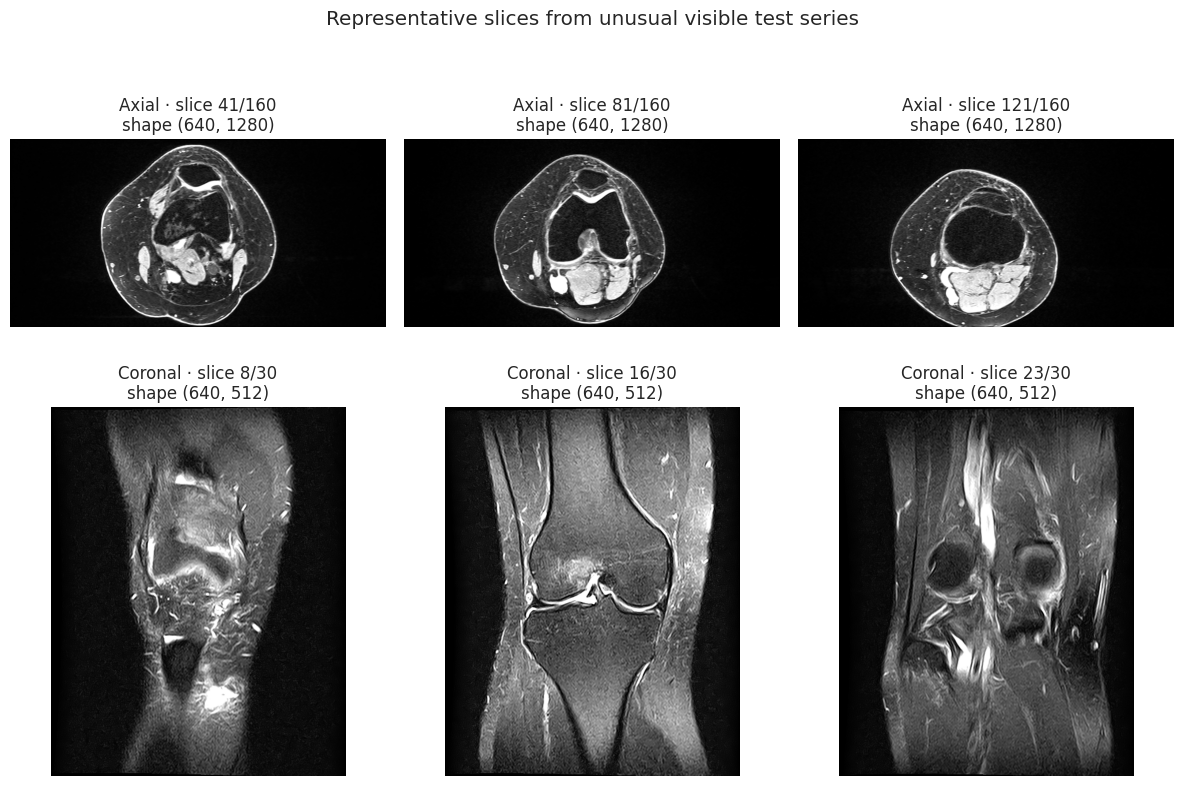

In [54]:
# 54. Decode representative slices from unusual visible test series

unusual_test_series = test_geometry.loc[
    (test_geometry["rows"] != test_geometry["columns"])
    | (
        test_geometry["number_of_files"]
        == test_geometry["number_of_files"].max()
    )
].drop_duplicates("SeriesInstanceUID")

if unusual_test_series.empty:
    print("No unusual visible test series were identified by these rules.")
else:
    figure_rows = len(unusual_test_series)
    fig, axes = plt.subplots(
        figure_rows,
        3,
        figsize=(12, 4 * figure_rows),
        squeeze=False,
    )

    for row_index, series_row in enumerate(
        unusual_test_series.itertuples(index=False)
    ):
        ordered_files = get_ordered_dicom_paths(
            getattr(series_row, ID_COLUMN),
            series_row.SeriesInstanceUID,
            TEST_IMAGES_ROOT,
        )

        slice_indices = sorted(set([
            len(ordered_files) // 4,
            len(ordered_files) // 2,
            3 * len(ordered_files) // 4,
        ]))

        for axis_index, ax in enumerate(axes[row_index]):
            if axis_index >= len(slice_indices):
                ax.axis("off")
                continue

            slice_index = slice_indices[axis_index]
            image, _ = load_display_image(
                ordered_files[slice_index]["path"]
            )
            ax.imshow(image, cmap="gray")
            ax.set_title(
                f"{series_row.anatomical_plane} · "
                f"slice {slice_index + 1}/{len(ordered_files)}\n"
                f"shape {image.shape}"
            )
            ax.axis("off")

    fig.suptitle("Representative slices from unusual visible test series")
    plt.tight_layout()
    plt.show()


### Observation — unusual test dimensions represent valid MRI acquisitions

The unusual visible test series decoded successfully and contain plausible knee anatomy across the inspected slices.

The 640 × 1,280 axial series contains substantial horizontal background padding around the anatomy, while the 640 × 512 coronal series uses a narrower portrait-shaped field of view. Neither series appears corrupted or contains concatenated images.

Preprocessing should preserve aspect ratio and avoid directly stretching these images to a square. Foreground-aware cropping followed by padding or aspect-ratio-preserving resizing is a more suitable starting point.

These findings apply only to the three visible test studies; hidden-test geometry may contain other patterns.

# Study-level modelling table

In [55]:
# 55. Assemble the fully labelled study-level table

gold_study_table = (
    train.loc[
        train[ID_COLUMN].isin(gold_study_ids),
        [ID_COLUMN] + TARGET_COLUMNS,
    ]
    .merge(
        study_imaging_summary.drop(columns="label_status"),
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

print(f"Gold-labelled studies: {len(gold_study_table):,}")
print(f"Columns in study-level table: {gold_study_table.shape[1]}")

display(gold_study_table.head())


Gold-labelled studies: 58
Columns in study-level table: 16


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture,number_of_series,fluid_sensitive_series,fluid_sensitive_percent
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,5,3,60.0000
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,9,4,44.4444
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,7,5,71.4286
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,5,4,80.0000
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,9,5,55.5556


### Observation — labels are defined at study level

The fully labelled table contains one row per study, combining the 12 targets with study-level imaging metadata. Series and slices from the same examination must therefore remain together during validation.

The patient-identifier audit found a distinct available `PatientID` for every gold study. No recorded patient therefore crosses the proposed validation folds.

# Validation strategy

In [56]:
# 56. Assess validation feasibility for each target

validation_feasibility = pd.DataFrame({
    "target": TARGET_COLUMNS,
    "positive_studies": [
        int(gold_study_table[target].sum())
        for target in TARGET_COLUMNS
    ],
})

validation_feasibility["negative_studies"] = (
    len(gold_study_table)
    - validation_feasibility["positive_studies"]
)

validation_feasibility["average_positives_per_3_fold"] = (
    validation_feasibility["positive_studies"] / 3
).round(2)

validation_feasibility["average_positives_per_5_fold"] = (
    validation_feasibility["positive_studies"] / 5
).round(2)

validation_feasibility = (
    validation_feasibility
    .sort_values("positive_studies")
    .reset_index(drop=True)
)

display(validation_feasibility)


,target,positive_studies,negative_studies,average_positives_per_3_fold,average_positives_per_5_fold
0,MCL,9,49,3.0000,1.8000
1,Lateral OA,11,47,3.6700,2.2000
2,Baker's,12,46,4.0000,2.4000
3,Medial OA,15,43,5.0000,3.0000
4,Fracture,18,40,6.0000,3.6000
5,Contusion,19,39,6.3300,3.8000
6,PF OA,21,37,7.0000,4.2000
7,Lateral Meniscus,23,35,7.6700,4.6000
8,ACL,24,34,8.0000,4.8000
9,Medial Meniscus,26,32,8.6700,5.2000


### Observation — validation is limited by rare positive targets

The 58 gold-labelled studies are sufficient for an initial validation scheme, but the rare targets provide very few positive cases per fold. This is especially true for MCL, Lateral OA and Baker's.

Three-fold validation should provide more stable estimates than five-fold validation, although even three-fold estimates will remain uncertain. Because each study has multiple targets, the folds should be created using multi-label stratification rather than balancing only one target or the total number of abnormalities.

Note: you may need to restart the kernel to use updated packages.


,number_of_folds,target,positive_cases_by_fold,minimum_positive_cases,maximum_positive_cases,negative_cases_by_fold
0,3,Lateral OA,"[3, 4, 4]",3,4,"[15, 16, 16]"
1,3,MCL,"[3, 3, 3]",3,3,"[15, 17, 17]"
2,3,Baker's,"[4, 4, 4]",4,4,"[14, 16, 16]"
3,3,Contusion,"[8, 5, 6]",5,8,"[10, 15, 14]"
4,3,Medial OA,"[5, 5, 5]",5,5,"[13, 15, 15]"
5,3,ACL,"[6, 8, 10]",6,10,"[12, 12, 10]"
6,3,Fracture,"[6, 6, 6]",6,6,"[12, 14, 14]"
7,3,PF OA,"[6, 7, 8]",6,8,"[12, 13, 12]"
8,3,Lateral Meniscus,"[8, 7, 8]",7,8,"[10, 13, 12]"
9,3,Medial Meniscus,"[9, 9, 8]",8,9,"[9, 11, 12]"


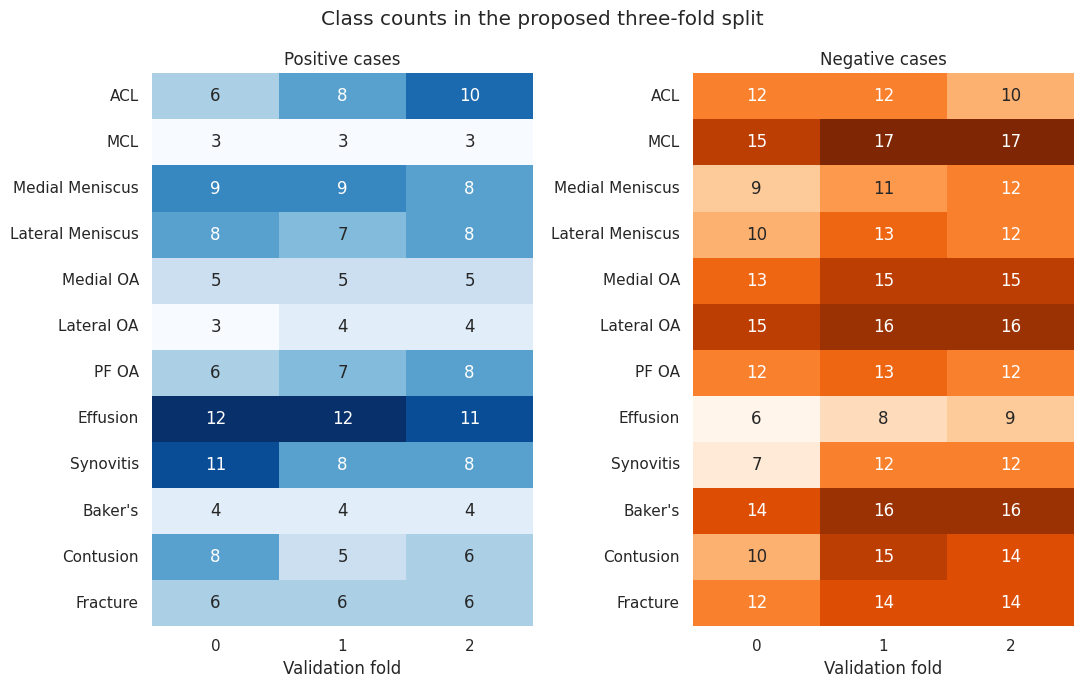

In [57]:
# 57. Inspect multi-label validation fold balance

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
except ImportError:
    %pip install -q iterative-stratification
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

gold_target_matrix = (
    gold_study_table[TARGET_COLUMNS]
    .to_numpy(dtype=int)
)

validation_assignments = gold_study_table[
    [ID_COLUMN]
].copy()

fold_balance_rows = []

for number_of_folds in [3, 5]:

    splitter = MultilabelStratifiedKFold(
        n_splits=number_of_folds,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    fold_numbers = np.full(
        len(gold_study_table),
        fill_value=-1,
        dtype=int,
    )

    for fold, (_, validation_indices) in enumerate(
        splitter.split(
            np.zeros((len(gold_target_matrix), 1)),
            gold_target_matrix,
        )
    ):
        fold_numbers[validation_indices] = fold

    validation_assignments[
        f"fold_{number_of_folds}"
    ] = fold_numbers

    for target in TARGET_COLUMNS:
        positive_counts = [
            int(
                gold_study_table.loc[
                    fold_numbers == fold,
                    target,
                ].sum()
            )
            for fold in range(number_of_folds)
        ]

        negative_counts = [
            int(
                (
                    gold_study_table.loc[
                        fold_numbers == fold,
                        target,
                    ] == 0
                ).sum()
            )
            for fold in range(number_of_folds)
        ]

        fold_balance_rows.append({
            "number_of_folds": number_of_folds,
            "target": target,
            "positive_cases_by_fold": positive_counts,
            "minimum_positive_cases": min(positive_counts),
            "maximum_positive_cases": max(positive_counts),
            "negative_cases_by_fold": negative_counts,
        })

fold_balance_summary = (
    pd.DataFrame(fold_balance_rows)
    .sort_values(
        ["number_of_folds", "minimum_positive_cases", "target"]
    )
    .reset_index(drop=True)
)

display(fold_balance_summary)

positive_fold_matrix = pd.DataFrame({
    fold: [
        int(
            gold_study_table.loc[
                validation_assignments["fold_3"] == fold,
                target,
            ].sum()
        )
        for target in TARGET_COLUMNS
    ]
    for fold in range(3)
}, index=TARGET_COLUMNS)

negative_fold_matrix = pd.DataFrame({
    fold: [
        int(
            (
                gold_study_table.loc[
                    validation_assignments["fold_3"] == fold,
                    target,
                ] == 0
            ).sum()
        )
        for target in TARGET_COLUMNS
    ]
    for fold in range(3)
}, index=TARGET_COLUMNS)

fig, axes = plt.subplots(1, 2, figsize=(11, 7))

sns.heatmap(
    positive_fold_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Positive cases")
axes[0].set_xlabel("Validation fold")
axes[0].set_ylabel("")

sns.heatmap(
    negative_fold_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("Negative cases")
axes[1].set_xlabel("Validation fold")
axes[1].set_ylabel("")

fig.suptitle("Class counts in the proposed three-fold split")
plt.tight_layout()
plt.show()


### Observation — three-fold validation is a pragmatic primary split

The multi-label stratification produces well-balanced three-fold splits. Every target has positive and negative cases in each fold, including the rare MCL target.

Five-fold validation leaves some folds with only one positive MCL case or two negative Effusion cases. Three folds are therefore a more stable pragmatic choice for initial comparison, although estimates remain highly uncertain and the split is not uniquely optimal.


In [58]:
# 58. Check duplicate reports across the proposed three-fold split

gold_report_folds = (
    gold_report_data[
        [ID_COLUMN, "normalized_report", "language"]
    ]
    .merge(
        validation_assignments[
            [ID_COLUMN, "fold_3"]
        ],
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

duplicate_report_fold_summary = (
    gold_report_folds
    .groupby("normalized_report", as_index=False)
    .agg(
        number_of_gold_studies=(ID_COLUMN, "size"),
        number_of_folds=("fold_3", "nunique"),
        folds=("fold_3", lambda values: sorted(values.unique())),
        languages=("language", lambda values: sorted(values.unique())),
    )
    .query("number_of_gold_studies > 1")
    .sort_values(
        ["number_of_gold_studies", "number_of_folds"],
        ascending=False,
    )
    .reset_index(drop=True)
)

cross_fold_duplicate_reports = duplicate_report_fold_summary[
    duplicate_report_fold_summary["number_of_folds"] > 1
]

print(
    "Duplicate normalized-report groups among gold-labelled studies:",
    len(duplicate_report_fold_summary),
)

print(
    "Duplicate groups split across validation folds:",
    len(cross_fold_duplicate_reports),
)

display(duplicate_report_fold_summary)


Duplicate normalized-report groups among gold-labelled studies: 0
Duplicate groups split across validation folds: 0


,normalized_report,number_of_gold_studies,number_of_folds,folds,languages


### Observation — gold-labelled reports do not duplicate across folds

No normalized report appears more than once among the gold-labelled studies. Therefore, the proposed three-fold split has no direct duplicate-report leakage within the gold-labelled validation data.

We still need to check whether any gold-labelled reports are duplicated among the report-only studies, because those reports may later be used for weak supervision.

In [59]:
# 59. Check overlap between gold-labelled and report-only reports

report_status_groups = (
    report_data
    .groupby("normalized_report", as_index=False)
    .agg(
        total_studies=(ID_COLUMN, "size"),
        gold_labelled_studies=(
            "label_status",
            lambda values: (values == "Gold-labelled").sum(),
        ),
        report_only_studies=(
            "label_status",
            lambda values: (values == "Report-only").sum(),
        ),
        example_report=("Report", "first"),
    )
)

gold_report_only_overlaps = (
    report_status_groups
    .query(
        "gold_labelled_studies > 0 "
        "and report_only_studies > 0"
    )
    .sort_values(
        ["gold_labelled_studies", "report_only_studies"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Report groups shared by gold-labelled and report-only studies:",
    len(gold_report_only_overlaps),
)

display(
    gold_report_only_overlaps[
        [
            "total_studies",
            "gold_labelled_studies",
            "report_only_studies",
            "example_report",
        ]
    ].head(15)
)


Report groups shared by gold-labelled and report-only studies: 1


,total_studies,gold_labelled_studies,report_only_studies,example_report
0,5,1,4,Technique: MRI of the knee. ACL normal. MCL no...


### Observation — one report template overlaps the labelled and report-only data

One normalized report appears once in the gold-labelled subset and four times in the report-only subset. Identical text does not prove that the corresponding images are duplicates, but it creates a direct text-leakage route if those reports are used for weak supervision.

The four report-only copies should therefore be excluded whenever the matching gold study is used for validation. This is a conservative report-level safeguard, not evidence about image similarity.


In [60]:
# 60. Inspect the shared gold/report-only report group

shared_normalized_reports = set(
    gold_report_only_overlaps["normalized_report"]
)

shared_report_details = (
    report_data.loc[
        report_data["normalized_report"].isin(
            shared_normalized_reports
        ),
        [
            ID_COLUMN,
            "label_status",
            "language",
            "Report",
        ],
    ]
    .merge(
        validation_assignments[
            [ID_COLUMN, "fold_3"]
        ],
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

shared_report_details["report_excerpt"] = (
    shared_report_details["Report"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 300)
)

display(
    shared_report_details[
        [
            ID_COLUMN,
            "label_status",
            "language",
            "fold_3",
            "report_excerpt",
        ]
    ]
)


,StudyInstanceUID,label_status,language,fold_3,report_excerpt
0,1.2.826.0.1.3680043.8.498.11295899132697862632...,Report-only,English,NaN,Technique: MRI of the knee. ACL normal. MCL no...
1,1.2.826.0.1.3680043.8.498.18680059761479598675...,Report-only,English,NaN,Technique: MRI of the knee. ACL normal. MCL no...
2,1.2.826.0.1.3680043.8.498.27437263843446879932...,Gold-labelled,English,1.0000,Technique: MRI of the knee. ACL normal. MCL no...
3,1.2.826.0.1.3680043.8.498.45865541491386404818...,Report-only,English,NaN,Technique: MRI of the knee. ACL normal. MCL no...
4,1.2.826.0.1.3680043.8.498.57836524675365700674...,Report-only,English,NaN,Technique: MRI of the knee. ACL normal. MCL no...


### Observation — the duplicated report maps to validation fold 1

The gold-labelled version of the repeated report is assigned to fold 1, while four identical report-only copies occur elsewhere in the training data. Those four report-only studies should be excluded from fold 1's weak-supervision training pool.

More generally, any prompt, rule set or report model used to create weak labels must be developed without using the held-out gold labels for that fold. Exact-text grouping addresses only one possible leakage route.


In [61]:
# 61. Create report-aware assignments for leakage-safe validation

gold_report_fold_map = (
    gold_report_folds[
        ["normalized_report", "fold_3"]
    ]
    .drop_duplicates()
)

assert (
    gold_report_fold_map
    .groupby("normalized_report")["fold_3"]
    .nunique()
    .le(1)
    .all()
)

report_validation_assignments = (
    report_data[
        [
            ID_COLUMN,
            "label_status",
            "normalized_report",
        ]
    ]
    .merge(
        gold_report_fold_map,
        on="normalized_report",
        how="left",
        validate="many_to_one",
    )
    .rename(columns={"fold_3": "excluded_validation_fold"})
)

report_only_overlap_summary = (
    report_validation_assignments
    .loc[
        (
            report_validation_assignments["label_status"]
            == "Report-only"
        )
        & report_validation_assignments[
            "excluded_validation_fold"
        ].notna()
    ]
    .groupby("excluded_validation_fold")
    .agg(
        report_only_rows_to_exclude=(ID_COLUMN, "size"),
        duplicated_report_groups=(
            "normalized_report",
            "nunique",
        ),
    )
    .reindex(range(3), fill_value=0)
    .rename_axis("validation_fold")
    .reset_index()
)

display(report_only_overlap_summary)


,validation_fold,report_only_rows_to_exclude,duplicated_report_groups
0,0,0,0
1,1,4,1
2,2,0,0


## Validation design decision

The proposed primary scheme uses three-fold multi-label stratification at the study level. It supplies at least three positive examples for every target in every validation fold and keeps the same assignments across initial experiments.

Every gold study has a distinct available `PatientID`, so the proposed assignments are also patient-independent within the provided identifiers.

For report-derived supervision, identical normalized reports are excluded from the relevant fold's training pool. Prompt design, extraction rules and threshold tuning must also be performed without consulting that fold's held-out gold labels.

In [62]:
# 62. Freeze the primary three-fold validation split

PRIMARY_N_FOLDS = 3
PRIMARY_FOLD_COLUMN = "fold_3"

primary_fold_assignments = (
    validation_assignments[
        [ID_COLUMN, PRIMARY_FOLD_COLUMN]
    ]
    .rename(
        columns={
            PRIMARY_FOLD_COLUMN: "validation_fold"
        }
    )
)

gold_study_table = (
    gold_study_table
    .drop(columns=["validation_fold"], errors="ignore")
    .merge(
        primary_fold_assignments,
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

assert len(gold_study_table) == 58
assert gold_study_table["validation_fold"].notna().all()
assert gold_study_table["validation_fold"].nunique() == 3

gold_study_table["number_of_positive_targets"] = (
    gold_study_table[TARGET_COLUMNS]
    .sum(axis=1)
    .astype(int)
)

primary_fold_summary = (
    gold_study_table
    .groupby("validation_fold")
    .agg(
        studies=(ID_COLUMN, "size"),
        total_positive_labels=(
            "number_of_positive_targets",
            "sum",
        ),
        mean_positive_labels=(
            "number_of_positive_targets",
            "mean",
        ),
        minimum_positive_labels=(
            "number_of_positive_targets",
            "min",
        ),
        maximum_positive_labels=(
            "number_of_positive_targets",
            "max",
        ),
    )
    .round(2)
    .reset_index()
)

display(primary_fold_summary)


,validation_fold,studies,total_positive_labels,mean_positive_labels,minimum_positive_labels,maximum_positive_labels
0,0,18,81,4.5000,1,8
1,1,20,78,3.9000,1,7
2,2,20,81,4.0500,1,9


### Observation — the primary validation folds are well balanced

The three validation folds contain similar numbers of studies and positive labels. Their average number of positive abnormalities per study is also comparable.

This provides a reasonable fixed study-level split for initial experiments. Because the labelled dataset is small, differences between folds will still contribute uncertainty to the evaluation, but the split is sufficiently balanced for a first baseline.

### Report-language composition across folds

Multi-label stratification balances targets, not report languages. We therefore inspect the language counts descriptively before freezing the split for report-based work.


language,Bulgarian,Croatian,Dutch,English,German,Greek,Spanish,Turkish
fold_3,,,,,,,,
0,1,2,1,7,2,2,3,0
1,1,1,0,11,0,1,3,3
2,1,1,1,10,0,0,4,3


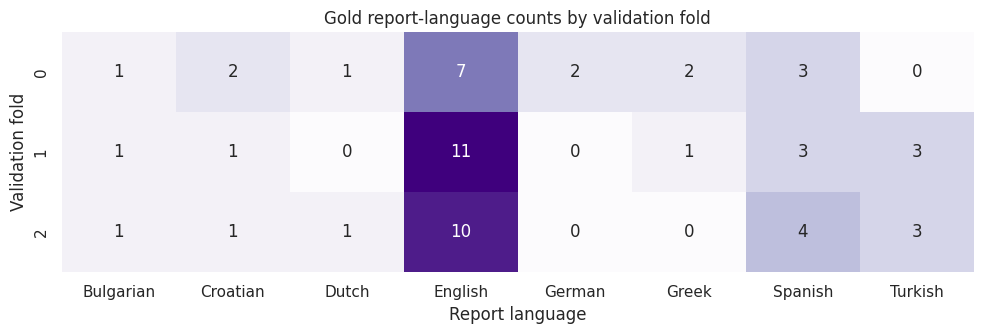

In [63]:
# 63. Inspect report-language composition across validation folds

fold_language_counts = (
    gold_report_folds
    .groupby(["fold_3", "language"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(PRIMARY_N_FOLDS), fill_value=0)
)

display(fold_language_counts)

plt.figure(figsize=(10, 3.5))
sns.heatmap(
    fold_language_counts,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
)
plt.title("Gold report-language counts by validation fold")
plt.xlabel("Report language")
plt.ylabel("Validation fold")
plt.tight_layout()
plt.show()


The language counts are descriptive rather than another optimisation target. With only 58 gold studies, forcing simultaneous balance across 12 labels and eight observed languages could destabilise the more important target balance. Any language imbalance should instead be reported when interpreting report-based results.


In [64]:
# 64. Create fixed study-level fold splits

fold_splits = {}

for fold in range(PRIMARY_N_FOLDS):

    validation_ids = set(
        gold_study_table.loc[
            gold_study_table["validation_fold"] == fold,
            ID_COLUMN,
        ]
    )

    training_ids = set(
        gold_study_table.loc[
            gold_study_table["validation_fold"] != fold,
            ID_COLUMN,
        ]
    )

    fold_splits[fold] = {
        "training_ids": training_ids,
        "validation_ids": validation_ids,
    }

    print(
        f"Fold {fold}: "
        f"{len(training_ids)} training studies, "
        f"{len(validation_ids)} validation studies"
    )


Fold 0: 40 training studies, 18 validation studies
Fold 1: 38 training studies, 20 validation studies
Fold 2: 38 training studies, 20 validation studies


## Validation metric

For each validation fold, performance will be reported separately for all 12 targets and as their macro-average.

The evaluator will explicitly identify any target with only one class in a fold, because ROC AUC cannot be calculated meaningfully in that situation.

In [65]:
# 65. Define the multi-label validation evaluator

from sklearn.metrics import roc_auc_score


def evaluate_multilabel_predictions(
    y_true,
    y_pred,
    target_columns=TARGET_COLUMNS,
):
    """
    Calculate per-target ROC AUC and the macro-average ROC AUC.
    """

    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    if y_true_array.ndim != 2 or y_pred_array.ndim != 2:
        raise ValueError("y_true and y_pred must be two-dimensional.")

    if y_true_array.shape != y_pred_array.shape:
        raise ValueError(
            "y_true and y_pred must have the same shape."
        )

    if not np.isfinite(y_pred_array).all():
        raise ValueError("y_pred contains non-finite values.")

    if y_true_array.shape[1] != len(target_columns):
        raise ValueError(
            "The number of prediction columns does not match "
            "the number of target columns."
        )

    metric_rows = []

    for target_index, target in enumerate(target_columns):

        target_values = y_true_array[:, target_index]
        unique_values = np.unique(target_values)

        if len(unique_values) < 2:
            auc = np.nan
            status = (
                "Undefined: validation fold contains "
                "only one class"
            )
        else:
            auc = roc_auc_score(
                target_values,
                y_pred_array[:, target_index],
            )
            status = "Valid"

        metric_rows.append({
            "target": target,
            "roc_auc": auc,
            "validation_classes": unique_values.tolist(),
            "status": status,
        })

    per_target_metrics = pd.DataFrame(metric_rows)

    valid_auc = per_target_metrics["roc_auc"].notna()

    summary_metrics = pd.DataFrame({
        "metric": [
            "Macro ROC AUC over valid targets",
            "Targets with valid ROC AUC",
            "Targets with undefined ROC AUC",
        ],
        "value": [
            per_target_metrics.loc[
                valid_auc,
                "roc_auc",
            ].mean(),
            int(valid_auc.sum()),
            int((~valid_auc).sum()),
        ],
    })

    return summary_metrics, per_target_metrics


print("Multi-label validation evaluator defined.")


Multi-label validation evaluator defined.


# Candidate imaging inputs

The following section defines a **proposed reduced-input baseline**, not a proven optimal series-selection policy. It asks whether fluid-sensitive series can provide consistent plane coverage while reducing the number of input series.

Non-fluid-sensitive series may still contain complementary information for some targets. Their value should be tested later against an all-series baseline.


In [66]:
# 66. Check sequence availability by study and anatomical plane

series_profile_rows = []

series_tables_for_profile = {
    "All train": train_series,
    "Gold-labelled": train_series[
        train_series[ID_COLUMN].isin(gold_study_ids)
    ],
    "Test": test_series,
}

for split_name, series_table in series_tables_for_profile.items():

    study_plane_counts = (
        series_table
        .groupby(
            [ID_COLUMN, "Anatomical_Plane"],
            as_index=False,
        )
        .agg(
            number_of_series=(
                "SeriesInstanceUID",
                "nunique",
            ),
            fluid_sensitive_series=(
                "Fluid_Sensitive",
                "sum",
            ),
        )
    )

    study_plane_counts["has_fluid_sensitive"] = (
        study_plane_counts["fluid_sensitive_series"] > 0
    )

    split_summary = (
        study_plane_counts
        .groupby("Anatomical_Plane")
        .agg(
            studies=(ID_COLUMN, "nunique"),
            median_series=("number_of_series", "median"),
            maximum_series=("number_of_series", "max"),
            studies_with_fluid_sensitive=(
                "has_fluid_sensitive",
                "sum",
            ),
        )
        .reset_index()
    )

    split_summary["fluid_sensitive_coverage_percent"] = (
        split_summary["studies_with_fluid_sensitive"]
        / split_summary["studies"]
        * 100
    )

    split_summary.insert(0, "split", split_name)
    series_profile_rows.append(split_summary)

sequence_availability_summary = (
    pd.concat(series_profile_rows, ignore_index=True)
    .assign(
        split=lambda frame: pd.Categorical(
            frame["split"],
            categories=[
                "All train",
                "Gold-labelled",
                "Test",
            ],
            ordered=True,
        ),
        Anatomical_Plane=lambda frame: pd.Categorical(
            frame["Anatomical_Plane"],
            categories=plane_order,
            ordered=True,
        ),
    )
    .sort_values(["split", "Anatomical_Plane"])
    .reset_index(drop=True)
    .round(2)
)

display(sequence_availability_summary)


,split,Anatomical_Plane,studies,median_series,maximum_series,studies_with_fluid_sensitive,fluid_sensitive_coverage_percent
0,All train,Axial,4407,1.0000,7,4407,100.0000
1,All train,Coronal,4407,2.0000,5,4248,96.3900
2,All train,Sagittal,4407,2.0000,6,4150,94.1700
3,Gold-labelled,Axial,58,1.0000,3,58,100.0000
4,Gold-labelled,Coronal,58,2.0000,4,56,96.5500
5,Gold-labelled,Sagittal,58,2.0000,5,56,96.5500
6,Test,Axial,3,1.0000,2,3,100.0000
7,Test,Coronal,3,1.0000,2,3,100.0000
8,Test,Sagittal,3,2.0000,3,2,66.6700


### Observation — fluid-sensitive series are common but not universal

Every training study has at least one fluid-sensitive axial series. Coverage is also high for coronal and sagittal series, but not complete: 159 training studies lack a fluid-sensitive coronal series and 257 lack one for sagittal imaging.

The gold-labelled subset follows the same pattern, and one of the three test studies has no fluid-sensitive sagittal series. We should therefore prefer fluid-sensitive series when available, but retain a deterministic fallback for studies without one.

In [67]:
# 67. Inspect study-plane combinations without fluid-sensitive series

def build_study_plane_profile(series_table, split_name):
    profile = (
        series_table
        .groupby(
            [ID_COLUMN, "Anatomical_Plane"],
            as_index=False,
        )
        .agg(
            number_of_series=(
                "SeriesInstanceUID",
                "nunique",
            ),
            fluid_sensitive_series=(
                "Fluid_Sensitive",
                "sum",
            ),
        )
    )

    profile.insert(0, "split", split_name)

    if split_name == "Train":
        profile.insert(
            1,
            "label_status",
            np.where(
                profile[ID_COLUMN].isin(gold_study_ids),
                "Gold-labelled",
                "Report-only",
            ),
        )
    else:
        profile.insert(1, "label_status", "Test")

    return profile


study_plane_profiles = pd.concat(
    [
        build_study_plane_profile(train_series, "Train"),
        build_study_plane_profile(test_series, "Test"),
    ],
    ignore_index=True,
)

missing_fluid_sensitive = study_plane_profiles[
    study_plane_profiles["fluid_sensitive_series"] == 0
].copy()

missing_summary = (
    study_plane_profiles
    .assign(
        missing_fluid_sensitive=lambda frame:
            frame["fluid_sensitive_series"] == 0
    )
    .groupby(
        ["split", "label_status", "Anatomical_Plane"],
        as_index=False,
    )
    .agg(
        study_plane_combinations=(
            ID_COLUMN,
            "nunique",
        ),
        combinations_without_fluid_sensitive=(
            "missing_fluid_sensitive",
            "sum",
        ),
    )
)

missing_summary["percentage_without_fluid_sensitive"] = (
    missing_summary["combinations_without_fluid_sensitive"]
    / missing_summary["study_plane_combinations"]
    * 100
)

missing_summary = (
    missing_summary
    .query("combinations_without_fluid_sensitive > 0")
    .sort_values(
        ["split", "label_status", "Anatomical_Plane"]
    )
    .reset_index(drop=True)
    .round(2)
)

missing_examples = (
    missing_fluid_sensitive
    .sort_values(
        ["split", "label_status", "Anatomical_Plane", ID_COLUMN]
    )
    .groupby(
        ["split", "label_status", "Anatomical_Plane"],
        group_keys=False,
    )
    .head(3)
    .reset_index(drop=True)
)

display(missing_summary)
display(missing_examples)


,split,label_status,Anatomical_Plane,study_plane_combinations,combinations_without_fluid_sensitive,percentage_without_fluid_sensitive
0,Test,Test,Sagittal,3,1,33.3300
1,Train,Gold-labelled,Coronal,58,2,3.4500
2,Train,Gold-labelled,Sagittal,58,2,3.4500
3,Train,Report-only,Coronal,4349,157,3.6100
4,Train,Report-only,Sagittal,4349,255,5.8600


,split,label_status,StudyInstanceUID,Anatomical_Plane,number_of_series,fluid_sensitive_series
0,Test,Test,1.2.826.0.1.3680043.8.498.10047035057544427318...,Sagittal,2,0
1,Train,Gold-labelled,1.2.826.0.1.3680043.8.498.48946580946665031852...,Coronal,1,0
2,Train,Gold-labelled,1.2.826.0.1.3680043.8.498.62465595376489211274...,Coronal,1,0
3,Train,Gold-labelled,1.2.826.0.1.3680043.8.498.73926443729786165628...,Sagittal,1,0
4,Train,Gold-labelled,1.2.826.0.1.3680043.8.498.97274720257634584071...,Sagittal,2,0
5,Train,Report-only,1.2.826.0.1.3680043.8.498.10077803906105306230...,Coronal,1,0
6,Train,Report-only,1.2.826.0.1.3680043.8.498.10085187975213640798...,Coronal,1,0
7,Train,Report-only,1.2.826.0.1.3680043.8.498.10144735099702632881...,Coronal,1,0
8,Train,Report-only,1.2.826.0.1.3680043.8.498.10158178668962379857...,Sagittal,1,0
9,Train,Report-only,1.2.826.0.1.3680043.8.498.10243300429607935614...,Sagittal,2,0


### Observation — fallback handling is required

Fluid-sensitive imaging is available for every axial study but is absent from a small proportion of coronal and sagittal study-plane combinations. The missing cases include four combinations in the gold subset and one sagittal combination in the visible test set.

For the proposed reduced-input baseline, these studies should retain their available non-fluid-sensitive series rather than be excluded.


In [68]:
# 68. Count eligible representative-series candidates

candidate_count_rows = []

series_tables_for_candidates = {
    "All train": train_series,
    "Gold-labelled": train_series[
        train_series[ID_COLUMN].isin(gold_study_ids)
    ],
    "Test": test_series,
}

for split_name, series_table in series_tables_for_candidates.items():

    candidate_table = series_table.copy()

    candidate_table["preferred_series"] = (
        candidate_table
        .groupby(
            [ID_COLUMN, "Anatomical_Plane"]
        )["Fluid_Sensitive"]
        .transform(
            lambda values: (
                values.eq(1)
                if values.eq(1).any()
                else pd.Series(
                    True,
                    index=values.index,
                )
            )
        )
    )

    eligible_candidate_counts = (
        candidate_table.loc[
            candidate_table["preferred_series"]
        ]
        .groupby(
            [ID_COLUMN, "Anatomical_Plane"],
            as_index=False,
        )
        .agg(
            eligible_series=(
                "SeriesInstanceUID",
                "nunique",
            ),
            uses_fluid_sensitive_preference=(
                "Fluid_Sensitive",
                "max",
            ),
        )
    )

    split_summary = (
        eligible_candidate_counts
        .groupby("Anatomical_Plane")
        .agg(
            study_plane_combinations=(
                ID_COLUMN,
                "size",
            ),
            combinations_with_one_candidate=(
                "eligible_series",
                lambda values: (values == 1).sum(),
            ),
            combinations_with_multiple_candidates=(
                "eligible_series",
                lambda values: (values > 1).sum(),
            ),
            maximum_candidates=(
                "eligible_series",
                "max",
            ),
        )
        .reset_index()
    )

    split_summary[
        "multiple_candidate_percent"
    ] = (
        split_summary[
            "combinations_with_multiple_candidates"
        ]
        / split_summary["study_plane_combinations"]
        * 100
    )

    split_summary.insert(0, "split", split_name)
    candidate_count_rows.append(split_summary)

representative_candidate_summary = (
    pd.concat(
        candidate_count_rows,
        ignore_index=True,
    )
    .assign(
        split=lambda frame: pd.Categorical(
            frame["split"],
            categories=[
                "All train",
                "Gold-labelled",
                "Test",
            ],
            ordered=True,
        ),
        Anatomical_Plane=lambda frame: pd.Categorical(
            frame["Anatomical_Plane"],
            categories=plane_order,
            ordered=True,
        ),
    )
    .sort_values(
        ["split", "Anatomical_Plane"]
    )
    .reset_index(drop=True)
    .round(2)
)

display(representative_candidate_summary)


,split,Anatomical_Plane,study_plane_combinations,combinations_with_one_candidate,combinations_with_multiple_candidates,maximum_candidates,multiple_candidate_percent
0,All train,Axial,4407,4109,298,3,6.7600
1,All train,Coronal,4407,4048,359,4,8.1500
2,All train,Sagittal,4407,3645,762,3,17.2900
3,Gold-labelled,Axial,58,53,5,2,8.6200
4,Gold-labelled,Coronal,58,50,8,3,13.7900
5,Gold-labelled,Sagittal,58,49,9,2,15.5200
6,Test,Axial,3,3,0,1,0.0000
7,Test,Coronal,3,3,0,1,0.0000
8,Test,Sagittal,3,1,2,2,66.6700


### Observation — sequence preference can retain multiple candidates

Preferring fluid-sensitive imaging produces a unique candidate for most study-plane combinations, but multiple candidates remain in 6.8% of axial, 8.2% of coronal and 17.3% of sagittal training combinations.

The proposed baseline therefore retains all preferred series and aggregates their predictions at study-plane level. This avoids an arbitrary identifier-based tie-break. It should later be compared with using all series and with quality-informed selection based on validated image characteristics.


In [69]:
# 69. Create the eligible series table

def select_eligible_series(series_table, split_name):
    selected = series_table.copy()

    selected["has_fluid_sensitive_in_plane"] = (
        selected
        .groupby(
            [ID_COLUMN, "Anatomical_Plane"]
        )["Fluid_Sensitive"]
        .transform("max")
        .astype(bool)
    )

    selected["selection_reason"] = np.where(
        selected["has_fluid_sensitive_in_plane"],
        "Fluid-sensitive",
        "Fallback: no fluid-sensitive series",
    )

    selected["is_eligible_series"] = (
        ~selected["has_fluid_sensitive_in_plane"]
        | selected["Fluid_Sensitive"].eq(1)
    )

    selected = (
        selected.loc[selected["is_eligible_series"]]
        .drop(
            columns=[
                "has_fluid_sensitive_in_plane",
                "is_eligible_series",
            ]
        )
        .assign(split=split_name)
        .reset_index(drop=True)
    )

    return selected


eligible_train_series = select_eligible_series(
    train_series,
    "Train",
)

eligible_test_series = select_eligible_series(
    test_series,
    "Test",
)

eligible_series = pd.concat(
    [
        eligible_train_series,
        eligible_test_series,
    ],
    ignore_index=True,
)

eligibility_validation = (
    eligible_series
    .groupby(
        ["split", ID_COLUMN, "Anatomical_Plane"],
        as_index=False,
    )
    .agg(
        eligible_series=(
            "SeriesInstanceUID",
            "nunique",
        ),
        selection_reason=(
            "selection_reason",
            "first",
        ),
    )
)

assert (
    eligibility_validation["eligible_series"] >= 1
).all()

original_study_plane_keys = set(
    pd.concat([
        train_series.assign(split="Train"),
        test_series.assign(split="Test"),
    ])[["split", ID_COLUMN, "Anatomical_Plane"]]
    .itertuples(index=False, name=None)
)

retained_study_plane_keys = set(
    eligibility_validation[
        ["split", ID_COLUMN, "Anatomical_Plane"]
    ].itertuples(index=False, name=None)
)

missing_study_plane_keys = (
    original_study_plane_keys - retained_study_plane_keys
)

assert not missing_study_plane_keys

selection_summary = (
    eligibility_validation
    .groupby(
        ["split", "Anatomical_Plane", "selection_reason"],
        as_index=False,
    )
    .agg(
        study_plane_combinations=(ID_COLUMN, "size"),
        total_eligible_series=("eligible_series", "sum"),
        maximum_eligible_series=("eligible_series", "max"),
    )
    .sort_values(
        ["split", "Anatomical_Plane", "selection_reason"]
    )
    .reset_index(drop=True)
)

print(
    "Eligible training series:",
    eligible_train_series["SeriesInstanceUID"].nunique(),
)

print(
    "Eligible test series:",
    eligible_test_series["SeriesInstanceUID"].nunique(),
)

print(
    "Study-plane combinations with no eligible series:",
    len(missing_study_plane_keys),
)

display(selection_summary)


Eligible training series: 14682
Eligible test series: 11
Study-plane combinations with no eligible series: 0


,split,Anatomical_Plane,selection_reason,study_plane_combinations,total_eligible_series,maximum_eligible_series
0,Test,Axial,Fluid-sensitive,3,3,1
1,Test,Coronal,Fluid-sensitive,3,3,1
2,Test,Sagittal,Fallback: no fluid-sensitive series,1,2,2
3,Test,Sagittal,Fluid-sensitive,2,3,2
4,Train,Axial,Fluid-sensitive,4407,4719,3
5,Train,Coronal,Fallback: no fluid-sensitive series,159,161,2
6,Train,Coronal,Fluid-sensitive,4248,4624,4
7,Train,Sagittal,Fallback: no fluid-sensitive series,257,511,3
8,Train,Sagittal,Fluid-sensitive,4150,4667,3


### Observation — the proposed subset preserves metadata-level plane coverage

The proposed rule retains 14,682 of 24,371 training series (60.2%) and 11 of 15 visible test series. Every study remains represented by at least one metadata row in each anatomical plane.

This is complete **study-plane coverage in the series metadata**. It is not proof that every retained directory or pixel array is valid, and the excluded 39.8% of training series may still contain useful complementary information.


In [70]:
# 70. Check eligible imaging volume across validation folds

gold_eligible_series = (
    eligible_train_series
    .merge(
        gold_study_table[
            [ID_COLUMN, "validation_fold"]
        ],
        on=ID_COLUMN,
        how="inner",
        validate="many_to_one",
    )
)

gold_fold_plane_profiles = (
    gold_eligible_series
    .groupby(
        [
            "validation_fold",
            ID_COLUMN,
            "Anatomical_Plane",
        ],
        as_index=False,
    )
    .agg(
        eligible_series=(
            "SeriesInstanceUID",
            "nunique",
        ),
        uses_fallback=(
            "selection_reason",
            lambda values:
                (
                    values
                    == "Fallback: no fluid-sensitive series"
                ).any(),
        ),
    )
)

fold_imaging_summary = (
    gold_fold_plane_profiles
    .groupby(
        ["validation_fold", "Anatomical_Plane"],
        as_index=False,
    )
    .agg(
        studies=(ID_COLUMN, "nunique"),
        total_eligible_series=(
            "eligible_series",
            "sum",
        ),
        mean_eligible_series_per_study=(
            "eligible_series",
            "mean",
        ),
        maximum_eligible_series=(
            "eligible_series",
            "max",
        ),
        studies_using_fallback=(
            "uses_fallback",
            "sum",
        ),
    )
    .sort_values(
        ["validation_fold", "Anatomical_Plane"]
    )
    .reset_index(drop=True)
    .round(2)
)

display(fold_imaging_summary)


,validation_fold,Anatomical_Plane,studies,total_eligible_series,mean_eligible_series_per_study,maximum_eligible_series,studies_using_fallback
0,0,Axial,18,19,1.0600,2,0
1,0,Coronal,18,23,1.2800,3,0
2,0,Sagittal,18,22,1.2200,2,2
3,1,Axial,20,22,1.1000,2,0
4,1,Coronal,20,21,1.0500,2,2
5,1,Sagittal,20,21,1.0500,2,0
6,2,Axial,20,22,1.1000,2,0
7,2,Coronal,20,23,1.1500,2,0
8,2,Sagittal,20,24,1.2000,2,0


### Observation — imaging volume is comparable across validation folds

The three validation folds contain similar eligible imaging volumes across all anatomical planes. Mean series counts range from 1.05 to 1.28 per study-plane combination, and every study retains axial, coronal and sagittal coverage.

The four gold-labelled fallback cases are not evenly distributed: two sagittal cases occur in fold 0 and two coronal cases occur in fold 1. This small difference does not justify altering the label-balanced split, but it should be remembered when interpreting fold-level results.

# Reproducible outputs

The proposed folds and candidate-series tables are exported so later modelling notebooks can load the exact assignments rather than regenerate them.


In [71]:
# 71. Export reusable validation and input-selection artifacts

import json

OUTPUT_DIRECTORY = Path("/kaggle/working/knee_eda_artifacts")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

primary_fold_assignments.to_csv(
    OUTPUT_DIRECTORY / "gold_study_validation_folds.csv",
    index=False,
)

report_validation_assignments[
    [ID_COLUMN, "label_status", "excluded_validation_fold"]
].to_csv(
    OUTPUT_DIRECTORY / "report_training_exclusions.csv",
    index=False,
)

eligible_train_series.to_csv(
    OUTPUT_DIRECTORY / "eligible_train_series.csv",
    index=False,
)

eligible_test_series.to_csv(
    OUTPUT_DIRECTORY / "eligible_test_series.csv",
    index=False,
)

artifact_metadata = {
    "random_state": RANDOM_STATE,
    "primary_number_of_folds": PRIMARY_N_FOLDS,
    "target_columns": TARGET_COLUMNS,
    "series_policy": (
        "retain all fluid-sensitive series within each study-plane; "
        "if none exist, retain all available series"
    ),
    "patient_grouping_note": (
        "Review the patient-grouping audit before treating study folds "
        "as patient-independent."
    ),
}

with (OUTPUT_DIRECTORY / "artifact_metadata.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(artifact_metadata, handle, indent=2)

print(f"Artifacts written to: {OUTPUT_DIRECTORY}")
for path in sorted(OUTPUT_DIRECTORY.iterdir()):
    print(f"  - {path.name}")


Artifacts written to: /kaggle/working/knee_eda_artifacts
  - artifact_metadata.json
  - eligible_test_series.csv
  - eligible_train_series.csv
  - gold_study_validation_folds.csv
  - report_training_exclusions.csv


# Conclusions, limitations and modelling implications

## Main findings

1. The training data contain 4,407 studies, but only 58 have complete gold-standard labels for all 12 abnormalities. The remaining 4,349 studies provide reports and imaging without structured targets.
2. All studies contain axial, coronal and sagittal series. Acquisition geometry, slice counts and pixel intensities vary substantially, so preprocessing must preserve aspect ratio and handle variable-length stacks deliberately.
3. Reports are complete but multilingual and structurally variable. They offer a potential source of weak supervision, although extraction quality cannot be assumed from the small, language-skewed gold subset.
4. One normalized report template crosses the gold and report-only subsets. Its four report-only copies must be excluded when the matching gold study is held out.
5. A fixed three-fold multi-label split is a pragmatic initial validation scheme: every target has positive and negative cases in each fold, unlike the less stable five-fold alternative.
6. A proposed fluid-sensitive input subset preserves study-plane coverage in the metadata while retaining 60.2% of training series. This is a computational baseline to test, not evidence that the excluded series are uninformative.

## Limitations

- The gold subset has no completely negative studies, so it cannot directly measure discrimination between entirely normal and abnormal knees.
- Every gold study has a distinct available `PatientID`, so no recorded patient crosses the validation folds. Because these identifiers are anonymised, unrecorded relationships cannot be ruled out completely.
- DICOM geometry, decoding and spatial-order checks are sample-based rather than exhaustive.
- Automatic language labels are approximate, and French has no gold-labelled reports.
- Only three test studies are visible, so their geometry cannot establish the hidden-test distribution.
- Report-derived labels must be created fold-safely: held-out gold labels cannot influence prompts, rules, thresholds or report models used for that fold.

## Recommended first experiments

Use the exported three-fold assignments for every comparison and report both per-target ROC AUC and the macro-average over all evaluable targets. Begin with a transparent image baseline, then compare all-series inputs against the proposed fluid-sensitive subset. Add report-derived supervision only through an explicitly fold-safe pipeline.
